# Circadiaan ML -- Stemming & Stress Voorspelling

**Project R.E.M. -- Notebook 1 van 4**

## Doel

Dit notebook voorspelt `mood_delta` (stemmingsverandering) en `stress_delta` (stressverandering)
na een luistersessie op basis van circadiaan afwijkingen, biometrische context en playlisttype.

**Onderzoeksvraag (RQ4):** *Kunnen we de stemmingsuitkomst voorspellen vanuit de fysiologische
toestand voor de sessie + het playlisttype?*

De kern van het model is de **circadiaan afwijking**: hoeveel wijkt iemands stress voor de
sessie af van hun verwachte stress op dat uur van de dag (gemeten op niet-sessiedagen)?
Een deelnemer die stressvoller is dan normaal reageert anders op een afspeellijst dan
iemand die op hun baseline zit -- dit is wat we proberen te kwantificeren.

> **RQ1 & RQ2 — zie `notebooks/visualisation/recovery_analysis.ipynb`**
> RQ1 (objectieve stressreductie): gemiddeld voordeel +46,9 min (betrouwbare subset, n=6; p=0,094, niet significant).
> RQ2 (stemming ↔ biometrie): correlatierichting positief, zie recovery notebook voor exacte r en p.
> RQ3 (biometrische classificatie van playlisttype) is onderzocht in sectie 7 van dit notebook.

## Modellen

| Model | Aard | Voornaamste beperking |
|---|---|---|
| DummyMean | Nulbaseline: altijd het gemiddelde voorspellen | -- |
| Ridge | Lineair, L2-regularisatie | Aanneemt lineaire relaties |
| Random Forest | Ensemble van beslisbomen | Kan overfitten bij kleine N |
| Gradient Boosting | Sequentieel boosten van zwakke leerders | Gevoelig voor overfitting bij kleine N |

Validatie: **leave-one-session-out (LOO) kruisvalidatie** -- met N=82 sessies is dit de meest
betrouwbare schatting van generalisatieprestatie. Imputatie vindt per fold plaats (mediaan van
de trainset) zodat er geen data-lekkage optreedt.

> **Let op -- mogelijke temporele volgorde:** `during_stress_mean` en `post_hr_mean` zijn
> biometrische gemiddelden ná de sessie. Controleer of de moodvragenlijst (basis van `mood_delta`)
> ná deze metingen is ingevuld. Als dit overlappen zijn het look-ahead features en moeten ze worden
> verwijderd uit het model.

## Gebruik

| Instelling | Betekenis |
|---|---|
| `REUSE_MODEL = True` | Laad opgeslagen modellen vanuit `models/circadian_ml/` (snel) |
| `REUSE_MODEL = False` | Train alle modellen opnieuw en sla op (~2 min bij N=82) |

Voer dit notebook volledig uit voor het starten van de Shiny-app: de app laadt
`models/circadian_ml/models.pkl` live bij opstarten voor per-moment aanbevelingen.

In [1]:
from __future__ import annotations

import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import shap
from IPython.display import display
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

## Configuratie

Pas `REUSE_MODEL` aan om modellen opnieuw te trainen of te laden.
`PARTICIPANTS = "all"` detecteert deelnemers automatisch vanuit de feature matrix.

In [2]:
# PARTICIPANTS: "all" -> auto-detecteer vanuit feature_matrix.csv
#               lijst  -> bijv. ["kokosnoot", "peer"]
PARTICIPANTS = "all"

# REUSE_MODEL: True  -> laad opgeslagen modellen (snel, aanbevolen)
#              False -> train opnieuw en sla op (~2 min)
REUSE_MODEL = True

# hrv_rmssd en avg_resp_daily zijn meegenomen maar hebben hoge NaN-fracties
# (63% en 13%). De median-imputatie in de Pipeline handelt dit per fold af.
FEATURE_COLS = [
    "baseline_deviation_entry",   # stress boven/onder circadiaan norm (primair signaal)
    "hr_baseline_deviation",      # HR boven/onder circadiaan norm
    "hour_of_day",                # tijdstip sessie
    "day_of_week",                # weekdag
    "playlist_calm",              # dummy: Calm playlist
    "playlist_energy",            # dummy: Energy playlist (Neutral = referentie)
    "mood_before_score",          # zelfgerapporteerde stemming voor sessie (1-10)
    "bb_start",                   # Body Battery bij start (Garmin, 0-100)
    "days_since_last_session",    # hersteltijd tussen sessies
    "during_stress_mean",         # gemiddelde stress tijdens sessie
    "post_stress_mean",           # gemiddelde stress na sessie
    "during_hr_mean",             # gemiddelde hartslag tijdens sessie
    "post_hr_mean",               # gemiddelde hartslag na sessie
    "pre_state_encoded",          # activiteitsklasse voor sessie (0=slaap..3=actief)
    "hrv_rmssd",                  # HRV (alleen peer heeft waarden)
    "avg_resp_daily",             # daggemiddelde ademhalingsfrequentie
]

TARGET_COLS = {
    "mood_delta":   "Stemming Delta",   # mood_after - mood_before
    "stress_delta": "Stress Delta",     # post_stress - pre_stress
}

# Ridge alpha=1.0: standaard L2-regularisatie (sklearn default).
# RF max_depth=3: beperkt boomdiepte tegen overfitting bij N<100.
# GB n_estimators=50, lr=0.1: bewust klein voor betere generalisatie.
MODELS = {
    "DummyMean":        DummyRegressor(strategy="mean"),
    "Ridge":            Ridge(alpha=1.0),
    "RandomForest":     RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=50, max_depth=2, learning_rate=0.1, random_state=42
    ),
}

In [3]:
PROJECT_ROOT        = Path().resolve().parent.parent
DATA_ROOT           = PROJECT_ROOT / "data"
ANALYSIS_DIR        = DATA_ROOT / "analysis"
COMBINED_DIR        = ANALYSIS_DIR / "circadian_baselines"
MODELS_DIR          = PROJECT_ROOT / "models" / "circadian_ml"
FEATURE_MATRIX_PATH = COMBINED_DIR / "feature_matrix.csv"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Donker thema (consistent met de Shiny-app)
plt.rcParams.update({
    "figure.facecolor": "#0f1218",
    "axes.facecolor":   "#181e2a",
    "axes.edgecolor":   "#4a5568",
    "axes.labelcolor":  "#e2e8f0",
    "xtick.color":      "#a0aec0",
    "ytick.color":      "#a0aec0",
    "text.color":       "#e2e8f0",
    "grid.color":       "#2d3748",
    "grid.alpha":       0.4,
    "legend.facecolor": "#1a2035",
    "legend.edgecolor": "#4a5568",
    "figure.dpi":       120,
    "font.family":      "monospace",
})

# Kleurenpalet: Okabe-Ito (kleurenblind-vriendelijk)
OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

## Hulpfuncties

`prepare_data` bereidt de feature matrix voor per target.
`run_loo_cv` voert leave-one-session-out kruisvalidatie uit met per-fold imputatie --
dit is de correcte volgorde om lekkage van testset-informatie via de imputer te voorkomen.

In [4]:
def prepare_data(
    feature_matrix_path: Path,
    target: str,
    participants: list[str],
) -> tuple:
    """
    Laad feature matrix, filter deelnemers, verwijder NaN-doelrijen.
    Imputatie vindt NIET hier plaats -- dat gebeurt per fold in run_loo_cv
    om data-lekkage te voorkomen.
    Participant-dummies worden toegevoegd zodat het model deelnemerseffecten kan leren.
    """
    fm = pd.read_csv(feature_matrix_path)
    fm = fm[fm["participant"].isin(participants)].reset_index(drop=True)
    fm = fm.dropna(subset=[target]).reset_index(drop=True)

    participant_dummies = pd.get_dummies(fm["participant"], prefix="p", drop_first=True)
    feature_cols = FEATURE_COLS + list(participant_dummies.columns)
    X = pd.concat([fm[FEATURE_COLS], participant_dummies], axis=1)
    y = fm[target]
    groups = fm["participant"]
    return X, y, feature_cols, groups


def _fit_pipeline(X: pd.DataFrame, y: pd.Series, model) -> Pipeline:
    """Fit imputatie + model op de volledige dataset.
    Gebruikt voor de finale fitted pipelines (SHAP/permutation importance).
    """
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   clone(model)),
    ])
    pipe.fit(X, y)
    return pipe


def run_loo_cv(X: pd.DataFrame, y: pd.Series, model) -> dict:
    """
    Leave-one-session-out CV met imputatie per fold.
    Per fold: imputer gefit op trainset, daarna toegepast op train + testset.
    Geeft MAE, RMSE, R2 (LOO), R2 (train gemiddeld) en overfitting-gap terug.
    """
    loo = LeaveOneOut()
    y_pred = np.full(len(y), np.nan)
    train_scores = []

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model",   clone(model)),
        ])
        pipe.fit(X_train, y_train)
        y_pred[test_idx] = pipe.predict(X_test)
        train_scores.append(pipe.score(X_train, y_train))

    mae           = mean_absolute_error(y, y_pred)
    rmse          = float(np.sqrt(mean_squared_error(y, y_pred)))
    r2            = r2_score(y, y_pred)
    train_r2_mean = float(np.mean(train_scores))

    return {
        "y_pred":        y_pred,
        "MAE":           mae,
        "RMSE":          rmse,
        "R2_LOO":        r2,
        "R2_train_mean": train_r2_mean,
        "overfit_gap":   train_r2_mean - r2,
    }


def train_and_evaluate(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    target_name: str,
) -> tuple:
    """LOO-CV voor alle modellen. Retourneert vergelijkingstabel + per-model resultaten."""
    results = {}
    rows    = []

    for name, model in MODELS.items():
        res = run_loo_cv(X, y, model)
        res["model_name"] = name
        results[name] = res

        row = {
            "model":         name,
            "MAE":           res["MAE"],
            "RMSE":          res["RMSE"],
            "R2_LOO":        res["R2_LOO"],
            "R2_train_mean": res["R2_train_mean"],
            "overfit_gap":   res["overfit_gap"],
        }

        for p in groups.unique():
            mask = groups == p
            if mask.sum() > 0:
                row[f"MAE_{p}"] = mean_absolute_error(y[mask], res["y_pred"][mask])

        rows.append(row)

    return pd.DataFrame(rows), results

## Data laden

De feature matrix bevat een rij per luistersessie (N~=82). Ze is gegenereerd door
`scripts/analysis/circadian_baseline.py` en combineert biometrische sessiedata
met circadiaan baselines en check-in stemmingsscores.

In [5]:
if not FEATURE_MATRIX_PATH.exists():
    raise FileNotFoundError(
        f"Feature matrix niet gevonden: {FEATURE_MATRIX_PATH}\n"
        "Voer eerst scripts/analysis/circadian_baseline.py uit."
    )

fm_raw = pd.read_csv(FEATURE_MATRIX_PATH)

if PARTICIPANTS == "all":
    participants = sorted(fm_raw["participant"].unique().tolist())
else:
    participants = list(PARTICIPANTS)

# `fm` is de gefilterde werkversie voor visualisatiecellen
fm = fm_raw[fm_raw["participant"].isin(participants)].copy()

print(f"Feature matrix geladen: {len(fm_raw)} sessies")
print(f"Deelnemers ({len(participants)}): {participants}")
print("Sessies per deelnemer:")
display(fm_raw["participant"].value_counts().to_frame())

Feature matrix geladen: 94 sessies
Deelnemers (4): ['bosbes', 'kokosnoot', 'limoen', 'peer']
Sessies per deelnemer:


,count
participant,
kokosnoot,42
peer,31
limoen,11
bosbes,10


## Model trainen / laden

Alle vier modellen draaien LOO-CV. Imputatie vindt per fold plaats zodat er geen lekkage is.

Naast de gefitte pipelines worden ook de volledige datasets opgeslagen in `models.pkl`.
De Shiny-app laadt dit bestand bij opstarten om per-moment aanbevelingen te genereren.

In [6]:
models_path = MODELS_DIR / "models.pkl"

if REUSE_MODEL:
    if not models_path.exists():
        raise FileNotFoundError(
            f"Opgeslagen modellen niet gevonden: {models_path}\n"
            "Zet REUSE_MODEL = False om de modellen opnieuw te trainen."
        )
    with open(models_path, "rb") as f:
        saved = pickle.load(f)
    all_comparisons = saved["comparisons"]
    all_results     = saved["results"]
    all_fitted      = saved["fitted"]
    all_X           = saved["X_data"]
    all_y           = saved["y_data"]
    all_groups      = saved["groups"]
    feature_names   = saved["feature_names"]
    print(f"Modellen geladen vanuit {models_path}")

else:
    all_comparisons = {}
    all_results     = {}
    all_fitted      = {}
    all_X           = {}
    all_y           = {}
    all_groups      = {}
    feature_names   = None

    for target, label in TARGET_COLS.items():
        print(f"\n{'─'*50}")
        print(f"Target: {label} ({target})")

        X, y, feat_names, groups = prepare_data(FEATURE_MATRIX_PATH, target, participants)
        feature_names = feat_names

        print(f"  Sessies: {len(y)} | Features: {len(feat_names)}")
        print(f"  Sessies per deelnemer: {dict(groups.value_counts())}")

        comparison, results = train_and_evaluate(X, y, groups, target)
        fitted = {name: _fit_pipeline(X, y, model) for name, model in MODELS.items()}

        all_comparisons[target] = comparison
        all_results[target]     = results
        all_fitted[target]      = fitted
        all_X[target]           = X
        all_y[target]           = y
        all_groups[target]      = groups

        COMBINED_DIR.mkdir(parents=True, exist_ok=True)
        comparison.to_csv(COMBINED_DIR / f"model_results_{target}.csv", index=False)
        print(f"  Opgeslagen: model_results_{target}.csv")

    with open(models_path, "wb") as f:
        pickle.dump({
            "comparisons":   all_comparisons,
            "results":       all_results,
            "fitted":        all_fitted,
            "X_data":        all_X,
            "y_data":        all_y,
            "groups":        all_groups,
            "feature_names": feature_names,
        }, f)
    print(f"\nModellen opgeslagen: {models_path}")

Modellen geladen vanuit /Users/timothydhoe/Code/spotify-project/models/circadian_ml/models.pkl


## Resultaten -- LOO-CV scores

Lagere MAE = betere voorspelling. R2 < 0 = slechter dan altijd het gemiddelde voorspellen.
**Overfitting-gap** = R2_train - R2_LOO: een grote kloof betekent dat het model de trainset
onthoudt maar niet generaliseert naar nieuwe sessies.

In [7]:
for target, label in TARGET_COLS.items():
    if target not in all_comparisons:
        print(f"Geen resultaten voor {target}")
        continue

    comparison = all_comparisons[target]
    y          = all_y[target]

    print(f"\n{'='*60}")
    print(f"  {label.upper()} ({target})  .  {len(y)} sessies")
    print(f"{'='*60}")

    display(
        comparison[["model", "MAE", "RMSE", "R2_LOO", "R2_train_mean", "overfit_gap"]]
        .round(3)
    )

    for _, row in comparison.iterrows():
        if row["model"] != "DummyMean" and row["overfit_gap"] > 0.5:
            print(f"  Overfit: {row['model']} -- train R2={row['R2_train_mean']:.3f} vs LOO R2={row['R2_LOO']:.3f}")

    non_dummy = comparison[comparison["model"] != "DummyMean"]
    best_row  = non_dummy.loc[non_dummy["MAE"].idxmin()]
    dummy_mae = comparison.loc[comparison["model"] == "DummyMean", "MAE"].values[0]
    print(f"  Beste model: {best_row['model']} (MAE={best_row['MAE']:.3f})")
    if best_row["MAE"] >= dummy_mae:
        print(
            f"  Geen model verslaat DummyMean (MAE={dummy_mae:.3f}) -- "
            f"features voorspellen {target} niet beter dan het gemiddelde (N={len(y)})."
        )
    else:
        gain = (dummy_mae - best_row["MAE"]) / dummy_mae * 100
        print(f"  {gain:.1f}% verbetering t.o.v. DummyMean")


  STEMMING DELTA (mood_delta)  .  82 sessies


,model,MAE,RMSE,R2_LOO,R2_train_mean,overfit_gap
0,DummyMean,1.817,2.460,-0.025,0.000,0.025
1,Ridge,1.578,2.007,0.318,0.587,0.269
2,RandomForest,1.666,2.128,0.233,0.681,0.448
3,GradientBoosting,1.778,2.295,0.108,0.820,0.712


  Overfit: GradientBoosting -- train R2=0.820 vs LOO R2=0.108
  Beste model: Ridge (MAE=1.578)
  13.2% verbetering t.o.v. DummyMean

  STRESS DELTA (stress_delta)  .  64 sessies


,model,MAE,RMSE,R2_LOO,R2_train_mean,overfit_gap
0,DummyMean,9.649,12.883,-0.032,0.000,0.032
1,Ridge,2.866,4.571,0.870,0.960,0.090
2,RandomForest,6.437,9.094,0.486,0.839,0.354
3,GradientBoosting,6.230,8.678,0.532,0.954,0.422


  Beste model: Ridge (MAE=2.866)
  70.3% verbetering t.o.v. DummyMean


### Interpretatie van de resultaten

**Ridge is het enige betrouwbare model bij N=82.**

| Model | LOO R² | Train R² | Overfitting gap | Conclusie |
|---|---|---|---|---|
| Ridge | 0.318 | 0.587 | 0.269 | Aanvaardbaar — gebruik voor rapportage |
| Random Forest | 0.233 | 0.681 | 0.448 | Hoog — resultaten zijn onbetrouwbaar |
| Gradient Boosting | 0.108 | 0.820 | **0.712** | Ernstig — model onthoudt trainset |

**Gradient Boosting**: train R²=0.820 vs LOO R²=0.108 — dit is een overfitting-kloof van 0.712.
Bij N=82 sessies heeft GB te veel vrijheidsgraden om generaliseerbaar te leren.
Presenteer alleen Ridge als conclusie; RF en GB worden getoond ter referentie.

**mood_before_score** is de sterkste predictor (ablatie: MAE stijgt van 1.578 → 2.126 zonder het).
Dit kan deels regressie-naar-het-gemiddelde zijn: wie hoog scoort voor de sessie heeft minder
ruimte om te stijgen. Zie sectie 6b voor de ablatie en de scatter in sectie 6c.

**stress_delta**: Ridge behaalt LOO R²=0.87 (indrukwekkend), maar generaliseert niet over
deelnemers — zie sectie 6a (LOPO) voor de volledige analyse.

---

## 1. Persoonlijke circadiaanse stresscurves

Elke deelnemer heeft een uniek dag-nachtpatroon in stress, berekend op **niet-sessiedagen**.
Dit is hun verwachte stress op elk uur van de dag -- de referentie waartegen
sessie-afwijkingen worden gemeten.

Grote uitschieten beinvloeden de `baseline_deviation_entry` feature: als iemand typisch
minder stress heeft in de ochtend, zal dezelfde gemeten stress 's ochtends een hogere
positieve afwijking geven dan diezelfde stress 's middags.

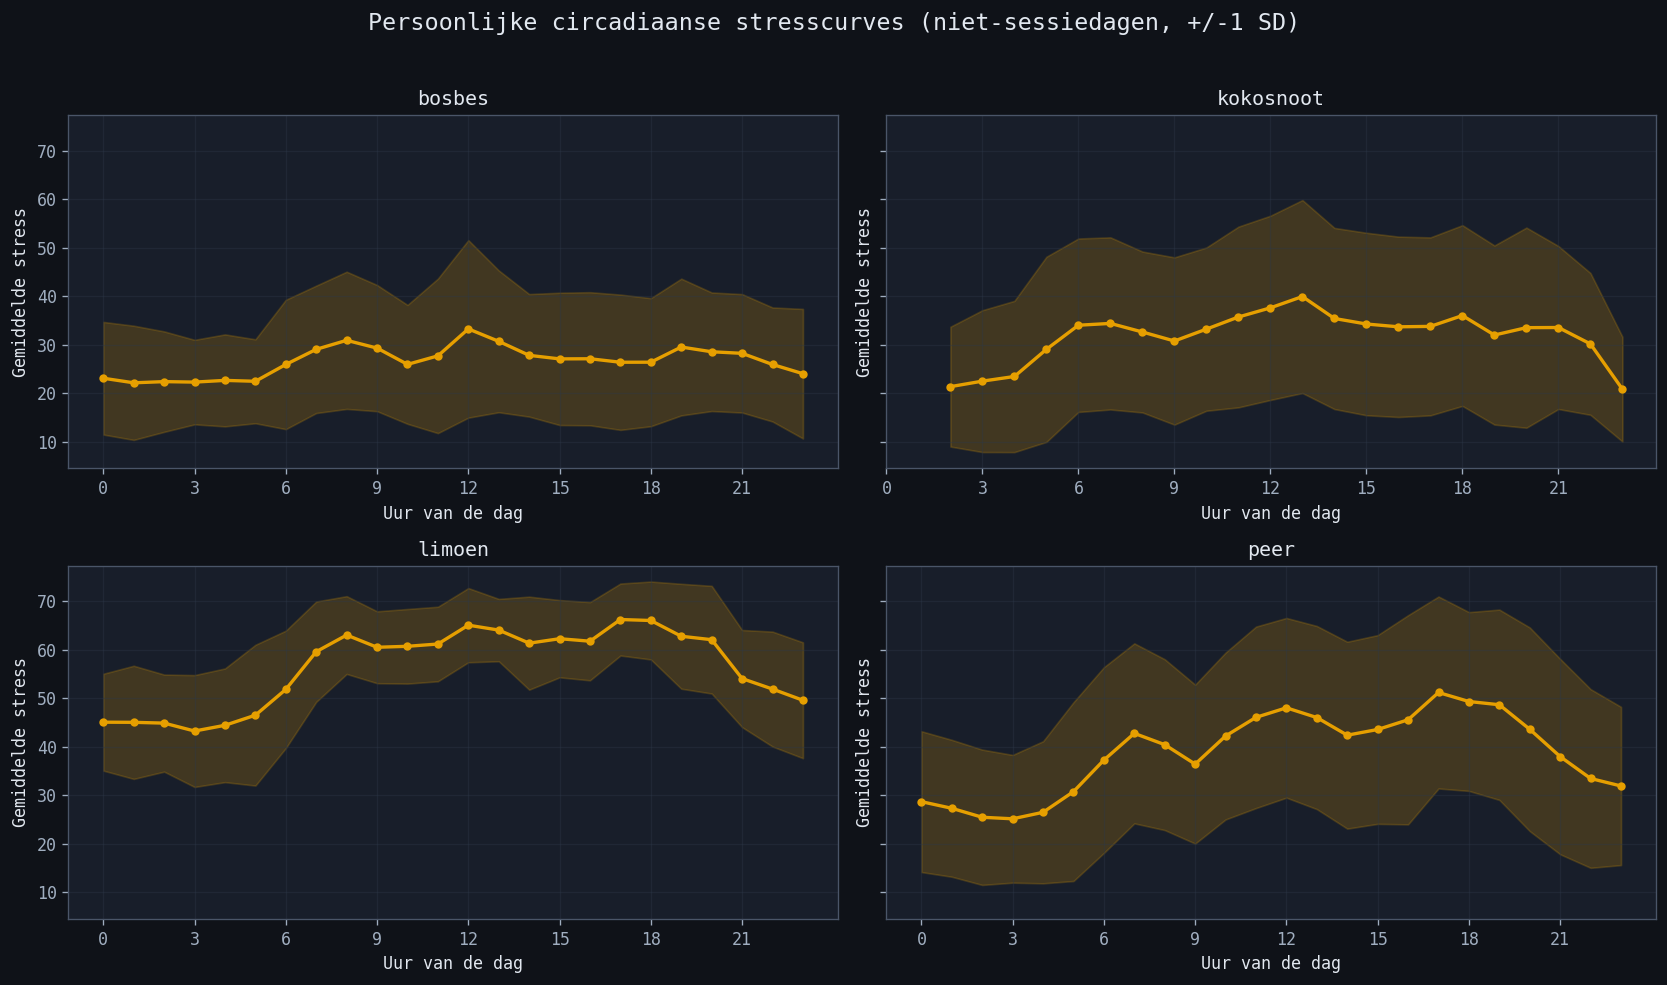

In [8]:
n = len(participants)
ncols = min(n, 2)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharey=True, squeeze=False)

for ax, p in zip(axes.flat, participants):
    bl_path = ANALYSIS_DIR / p / "circadian_baselines" / "hourly_baseline.csv"
    if bl_path.exists():
        bl = pd.read_csv(bl_path)
        valid = bl["mean_stress"].notna()
        ax.plot(bl["hour"], bl["mean_stress"], "o-", linewidth=2,
                markersize=4, color=OKABE_ITO[0])
        ax.fill_between(
            bl.loc[valid, "hour"],
            bl.loc[valid, "mean_stress"] - bl.loc[valid, "std_stress"],
            bl.loc[valid, "mean_stress"] + bl.loc[valid, "std_stress"],
            alpha=0.2, color=OKABE_ITO[0],
        )
        ax.set_title(p, fontsize=12)
        ax.set_xticks(range(0, 24, 3))
        ax.set_xlabel("Uur van de dag")
        ax.set_ylabel("Gemiddelde stress")
        ax.grid(True)
    else:
        ax.text(0.5, 0.5, f"Geen baseline voor {p}", ha="center", va="center",
                transform=ax.transAxes)

for ax in axes.flat[n:]:
    ax.set_visible(False)

fig.suptitle("Persoonlijke circadiaanse stresscurves (niet-sessiedagen, +/-1 SD)",
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

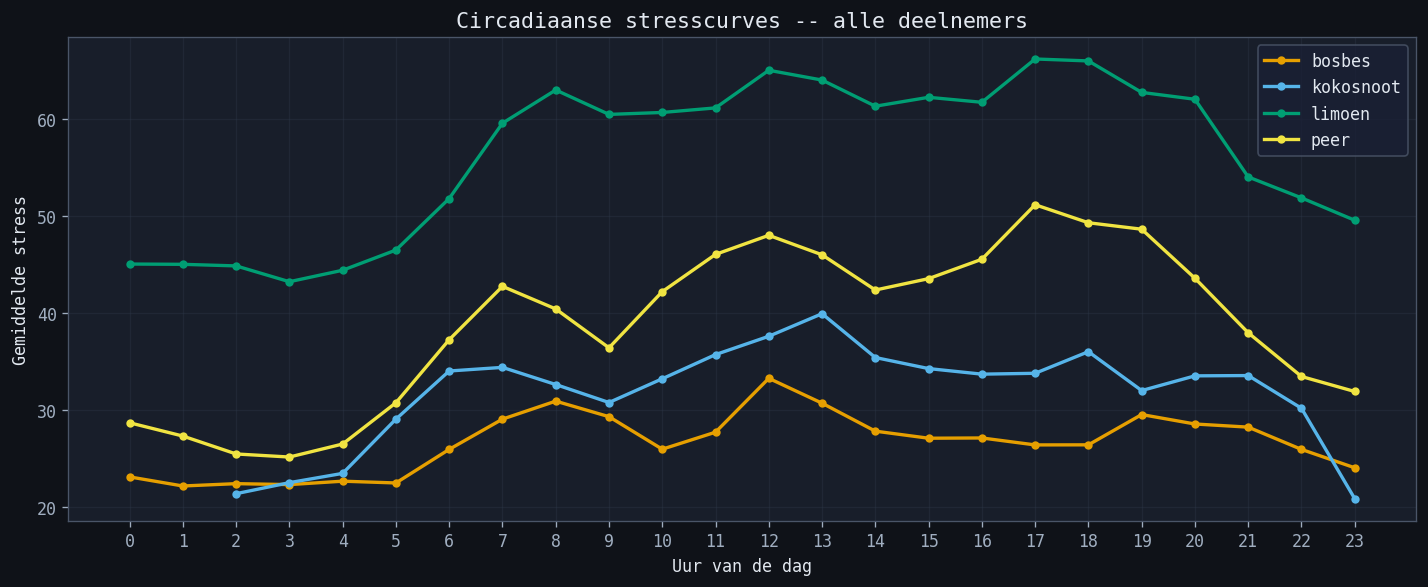

In [9]:
# Overlay: alle deelnemers in een grafiek voor vergelijking
fig, ax = plt.subplots(figsize=(12, 5))

for i, p in enumerate(participants):
    bl_path = ANALYSIS_DIR / p / "circadian_baselines" / "hourly_baseline.csv"
    if bl_path.exists():
        bl = pd.read_csv(bl_path)
        ax.plot(bl["hour"], bl["mean_stress"], "o-",
                label=p, color=OKABE_ITO[i % len(OKABE_ITO)], linewidth=2, markersize=4)

ax.set_xlabel("Uur van de dag")
ax.set_ylabel("Gemiddelde stress")
ax.set_title("Circadiaanse stresscurves -- alle deelnemers", fontsize=13)
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

## 2. Feature matrix -- overzicht

Een rij per luistersessie. De features combineren circadiaan afwijkingen, tijdscontext,
playlisttype, zelfgerapporteerde stemming en biometrische context.

**NaN-fracties:** `hrv_rmssd` (63% NaN) is hoog omdat niet alle Garmin-modellen HRV meten.
`post_hr_mean` (40%) ontbreekt als de deelnemer de smartwatch niet droeg na de sessie.
De median-imputatie per fold handelt dit op een lekkageveilige manier af.

In [10]:
print(f"Totaal sessies: {len(fm)}")
print("\nSessies per deelnemer:")
display(fm["participant"].value_counts().to_frame())

print("\nNaN per feature (model inputs):")
nan_pct = (fm[FEATURE_COLS].isna().mean() * 100).round(1)
nan_df  = pd.DataFrame({"NaN count": fm[FEATURE_COLS].isna().sum(), "NaN %": nan_pct})
display(nan_df[nan_df["NaN count"] > 0].sort_values("NaN %", ascending=False))

Totaal sessies: 94

Sessies per deelnemer:


,count
participant,
kokosnoot,42
peer,31
limoen,11
bosbes,10



NaN per feature (model inputs):


,NaN count,NaN %
hrv_rmssd,64,68.1
post_hr_mean,42,44.7
during_hr_mean,41,43.6
hr_baseline_deviation,34,36.2
pre_state_encoded,31,33.0
during_stress_mean,24,25.5
baseline_deviation_entry,23,24.5
post_stress_mean,23,24.5
bb_start,21,22.3
avg_resp_daily,20,21.3


In [11]:
print("Feature samenvatting (model inputs + targets):")
display(fm[FEATURE_COLS + ["mood_delta", "stress_delta"]].describe().round(2))

Feature samenvatting (model inputs + targets):


,baseline_deviation_entry,hr_baseline_deviation,hour_of_day,day_of_week,playlist_calm,playlist_energy,mood_before_score,bb_start,days_since_last_session,during_stress_mean,post_stress_mean,during_hr_mean,post_hr_mean,pre_state_encoded,hrv_rmssd,avg_resp_daily,mood_delta,stress_delta
count,71.00,60.00,94.00,94.00,94.00,94.00,94.00,73.00,90.00,70.00,71.00,53.00,52.00,63.00,30.00,74.00,94.00,68.00
mean,0.43,0.00,11.61,2.35,0.34,0.45,6.66,47.68,5.02,38.28,37.73,82.88,83.78,0.79,26.60,15.16,-0.14,-1.04
std,13.63,8.23,4.07,1.76,0.48,0.50,1.71,21.13,5.90,14.40,13.32,9.79,10.64,0.41,4.30,1.27,2.35,12.53
min,-29.45,-15.33,6.00,0.00,0.00,0.00,3.00,5.00,0.00,8.90,16.70,60.60,64.30,0.00,17.00,13.00,-8.00,-30.60
25%,-9.63,-5.32,8.00,1.00,0.00,0.00,5.00,30.00,1.00,29.22,27.75,77.20,77.68,1.00,23.25,14.00,-1.00,-7.85
50%,0.58,-1.27,11.00,2.00,0.00,0.00,6.50,47.00,2.00,36.10,36.20,84.20,84.45,1.00,27.50,15.00,0.00,-0.60
75%,7.63,5.31,14.00,4.00,1.00,1.00,8.00,66.00,7.00,46.95,44.15,89.90,88.68,1.00,29.00,16.00,1.00,5.20
max,32.79,28.39,22.00,6.00,1.00,1.00,10.00,84.00,41.00,91.00,77.90,102.20,106.10,1.00,36.00,18.00,7.00,41.60


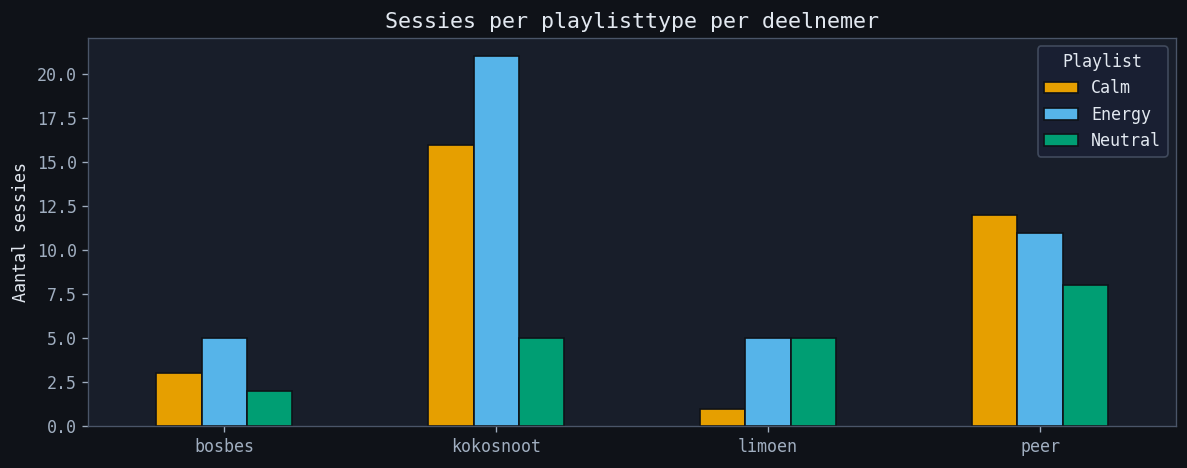

In [12]:
# Playlistdistributie per deelnemer
def playlist_label(row):
    if row["playlist_calm"] == 1:   return "Calm"
    if row["playlist_energy"] == 1: return "Energy"
    return "Neutral"

fm["playlist_type"] = fm.apply(playlist_label, axis=1)
dist = fm.groupby(["participant", "playlist_type"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
dist.plot(kind="bar", ax=ax, color=OKABE_ITO[:3], edgecolor="#0f1218")
ax.set_title("Sessies per playlisttype per deelnemer", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Aantal sessies")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Playlist")
fig.tight_layout()
plt.show()

## 3. Modelresultaten -- visualisatie

LOO-CV scores voor beide targets, per model en per deelnemer.
Ridge generaliseert het best voor `mood_delta`; voor `stress_delta` behaalt
Ridge LOO-R2=0.87 (70% beter dan DummyMean).

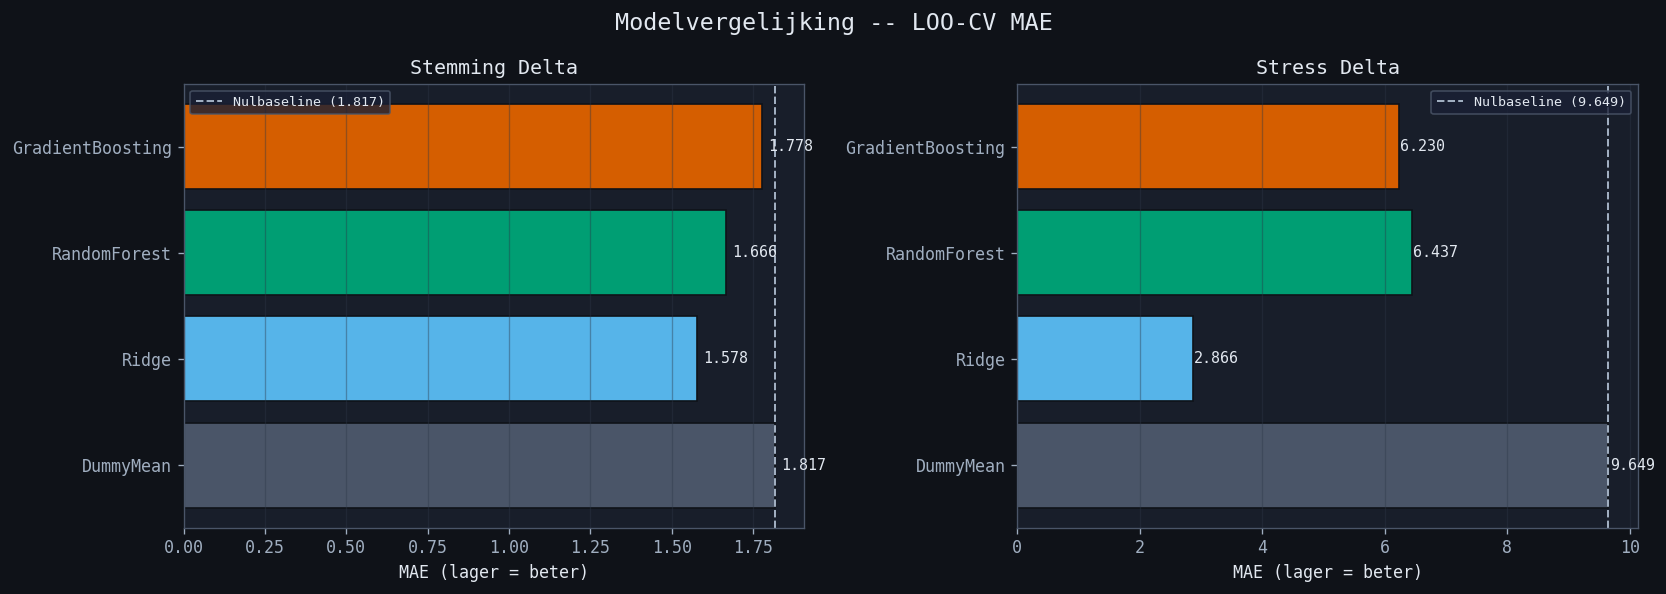

In [13]:
MODEL_COLORS = {
    "DummyMean":        "#4a5568",   # grijs
    "Ridge":            OKABE_ITO[1],  # blauw
    "RandomForest":     OKABE_ITO[2],  # groen
    "GradientBoosting": OKABE_ITO[5],  # rood-oranje
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (target, label) in zip(axes, TARGET_COLS.items()):
    if target not in all_comparisons:
        continue
    comparison  = all_comparisons[target]
    dummy_mae   = comparison.loc[comparison["model"] == "DummyMean", "MAE"].values[0]
    colors      = [MODEL_COLORS.get(m, OKABE_ITO[0]) for m in comparison["model"]]

    bars = ax.barh(comparison["model"], comparison["MAE"],
                   color=colors, edgecolor="#0f1218")
    for bar, v in zip(bars, comparison["MAE"]):
        ax.text(v + 0.02, bar.get_y() + bar.get_height() / 2,
                f"{v:.3f}", va="center", fontsize=9)

    ax.axvline(dummy_mae, color="#a0aec0", linewidth=1.2, linestyle="--",
               label=f"Nulbaseline ({dummy_mae:.3f})")
    ax.set_xlabel("MAE (lager = beter)")
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, axis="x")

fig.suptitle("Modelvergelijking -- LOO-CV MAE", fontsize=14)
fig.tight_layout()
plt.show()

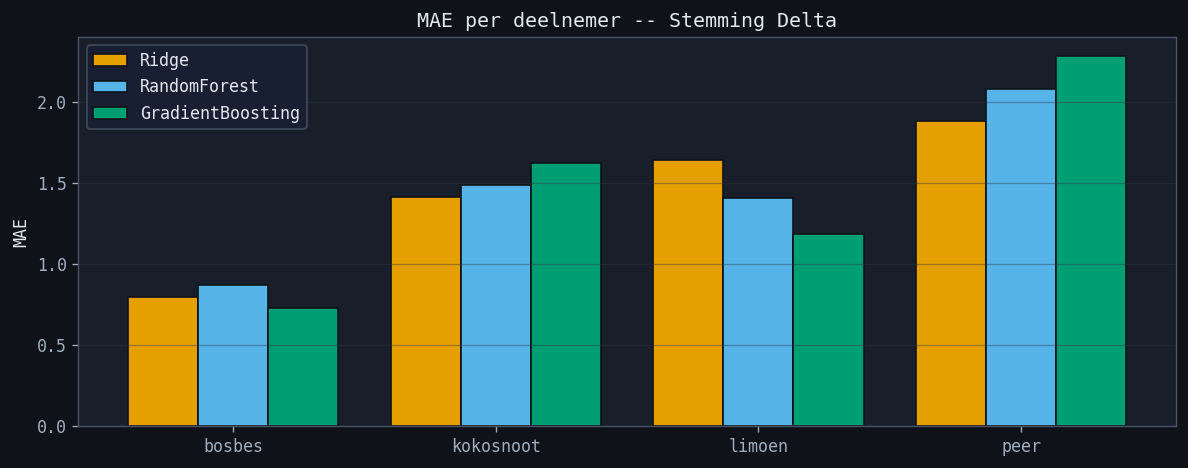

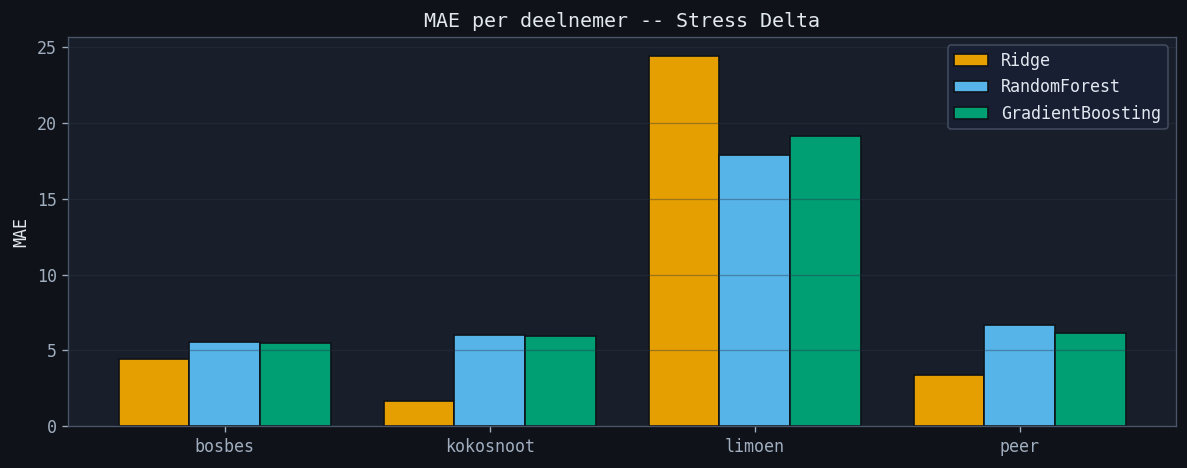

In [14]:
# Per-deelnemer MAE
for target, label in TARGET_COLS.items():
    if target not in all_comparisons:
        continue
    comparison = all_comparisons[target]
    mae_cols   = [c for c in comparison.columns if c.startswith("MAE_")]
    if not mae_cols:
        continue
    parts     = [c.replace("MAE_", "") for c in mae_cols]
    non_dummy = comparison[comparison["model"] != "DummyMean"].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 4))
    x     = np.arange(len(parts))
    width = 0.8 / len(non_dummy)

    for i, (_, row) in enumerate(non_dummy.iterrows()):
        vals = [row[c] for c in mae_cols]
        ax.bar(x + i * width, vals, width,
               label=row["model"], color=OKABE_ITO[i % len(OKABE_ITO)], edgecolor="#0f1218")

    ax.set_xticks(x + width * (len(non_dummy) - 1) / 2)
    ax.set_xticklabels(parts)
    ax.set_ylabel("MAE")
    ax.set_title(f"MAE per deelnemer -- {label}", fontsize=12)
    ax.legend()
    ax.grid(True, axis="y")
    fig.tight_layout()
    plt.show()

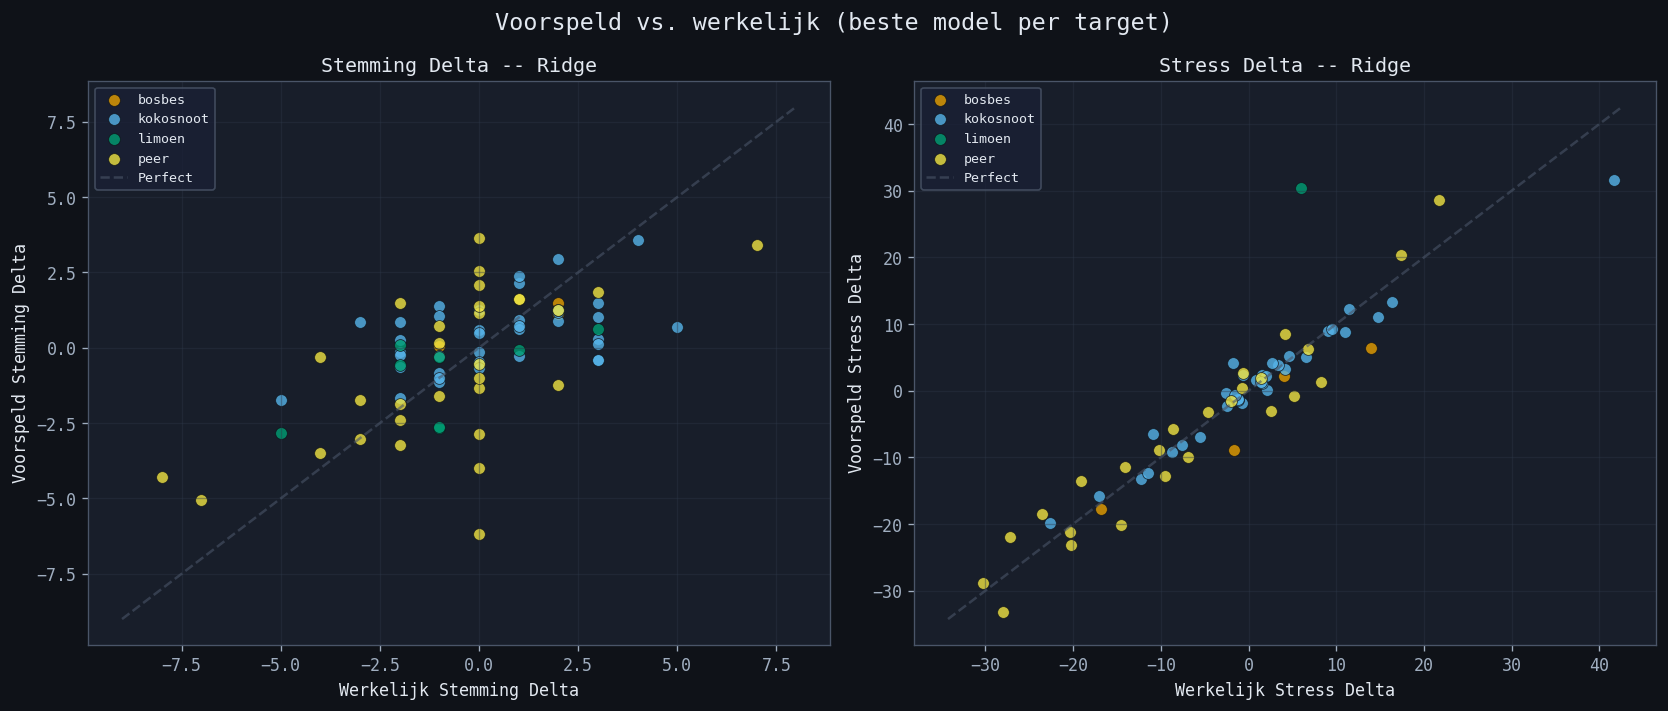

In [15]:
# Voorspeld vs. werkelijk -- beste model per target
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (target, label) in zip(axes, TARGET_COLS.items()):
    if target not in all_comparisons:
        continue
    comparison = all_comparisons[target]
    non_dummy  = comparison[comparison["model"] != "DummyMean"]
    best_name  = non_dummy.loc[non_dummy["MAE"].idxmin(), "model"]
    y_true     = all_y[target]
    y_pred     = all_results[target][best_name]["y_pred"]
    groups     = all_groups[target]

    for i, p in enumerate(groups.unique()):
        mask = groups == p
        ax.scatter(y_true[mask], y_pred[mask],
                   label=p, color=OKABE_ITO[i % len(OKABE_ITO)],
                   alpha=0.8, s=50, edgecolors="#0f1218", linewidths=0.5)

    mn = min(float(y_true.min()), float(y_pred.min())) - 1
    mx = max(float(y_true.max()), float(y_pred.max())) + 1
    ax.plot([mn, mx], [mn, mx], "--", color="#4a5568", alpha=0.6, label="Perfect")
    ax.set_xlabel(f"Werkelijk {label}")
    ax.set_ylabel(f"Voorspeld {label}")
    ax.set_title(f"{label} -- {best_name}", fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True)

fig.suptitle("Voorspeld vs. werkelijk (beste model per target)", fontsize=14)
fig.tight_layout()
plt.show()

## 4. Verklarende analyse

**Belangrijk voorbehoud:** Ridge coefficienten, permutation importance en SHAP zijn
*verklarend van het model* -- ze beschrijven hoe het model werkt, niet de onderliggende
werkelijkheid. Met N < 100 sessies en hoge NaN-fracties zijn dit richtingwijzers,
geen causale uitspraken.

### 4a. Ridge coefficienten

Ridge legt een L2-straf op grote coefficienten, waardoor features met weinig
voorspelkracht naar nul worden gedrukt. Grote absolute waarden duiden op features
die het model sterk weegt. Positief = hogere feature-waarde leidt tot hogere voorspelde target.
Zie: [sklearn Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

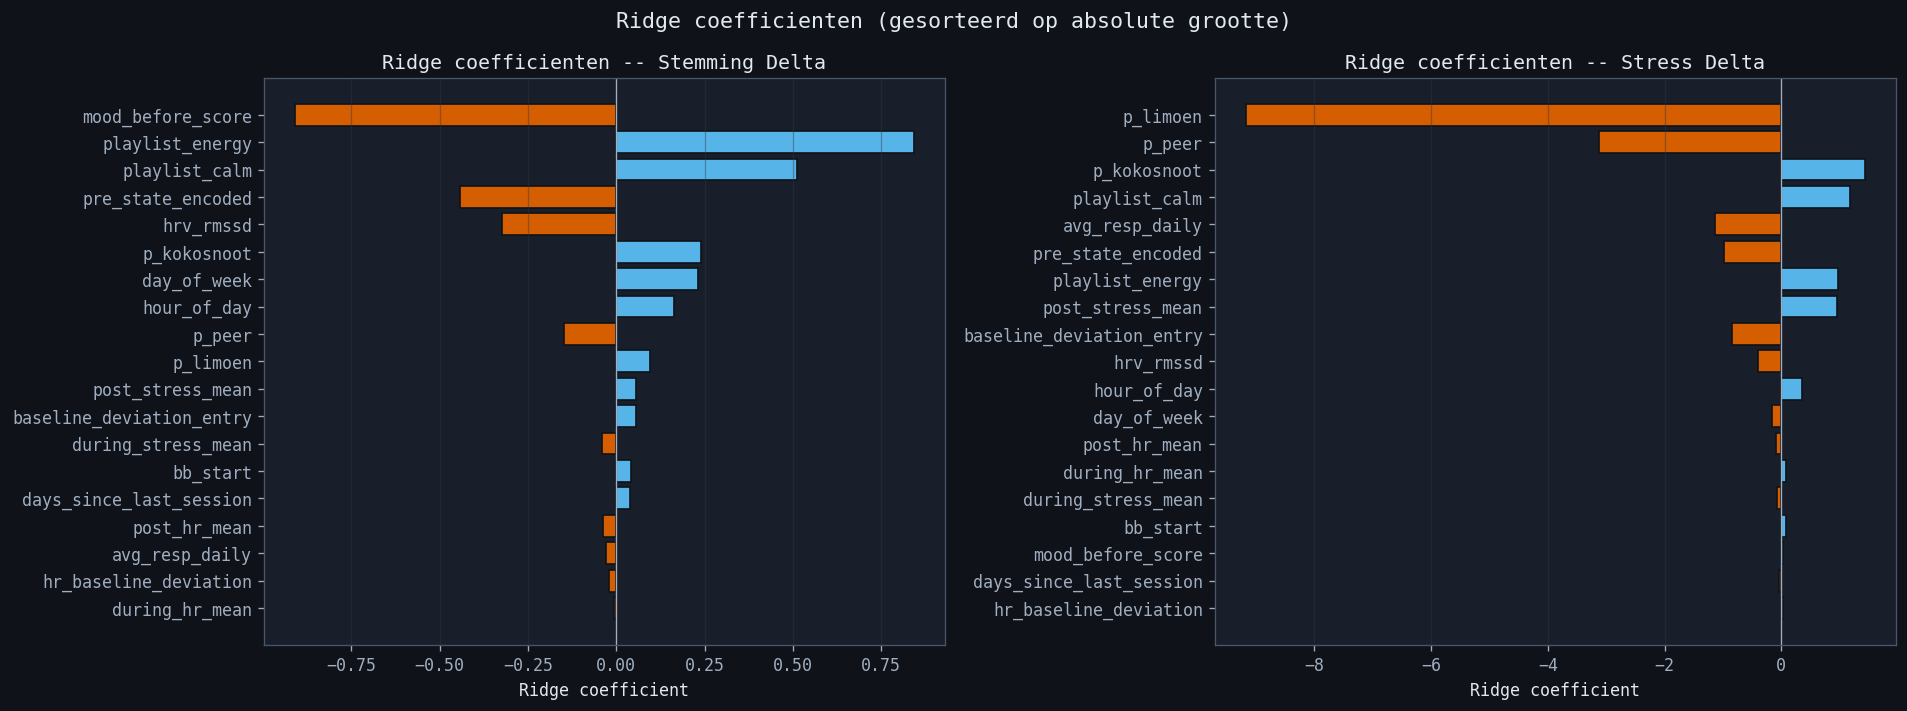

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (target, label) in zip(axes, TARGET_COLS.items()):
    if target not in all_fitted:
        continue
    pipe  = all_fitted[target]["Ridge"]
    X     = all_X[target]
    coefs = pipe.named_steps["model"].coef_
    names = feature_names if feature_names else list(X.columns)

    coef_df = pd.DataFrame({"feature": names, "coef": coefs})
    coef_df = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=True).index)
    colors  = [OKABE_ITO[5] if c < 0 else OKABE_ITO[1] for c in coef_df["coef"]]

    ax.barh(coef_df["feature"], coef_df["coef"], color=colors, edgecolor="#0f1218")
    ax.axvline(0, color="#a0aec0", linewidth=0.8)
    ax.set_xlabel("Ridge coefficient")
    ax.set_title(f"Ridge coefficienten -- {label}", fontsize=12)
    ax.grid(True, axis="x")

fig.suptitle("Ridge coefficienten (gesorteerd op absolute grootte)", fontsize=13)
fig.tight_layout()
plt.show()

### 4b. Permutation importance

Permutation importance meet hoeveel de MAE stijgt wanneer een feature willekeurig
wordt gewisseld (30 herhalingen). Hogere stijging = feature is belangrijker voor het model.

Zie: [sklearn permutation_importance](https://scikit-learn.org/stable/modules/permutation_importance.html)

Let op: permutation importance meet correlatie met de target via het model, niet causaliteit.

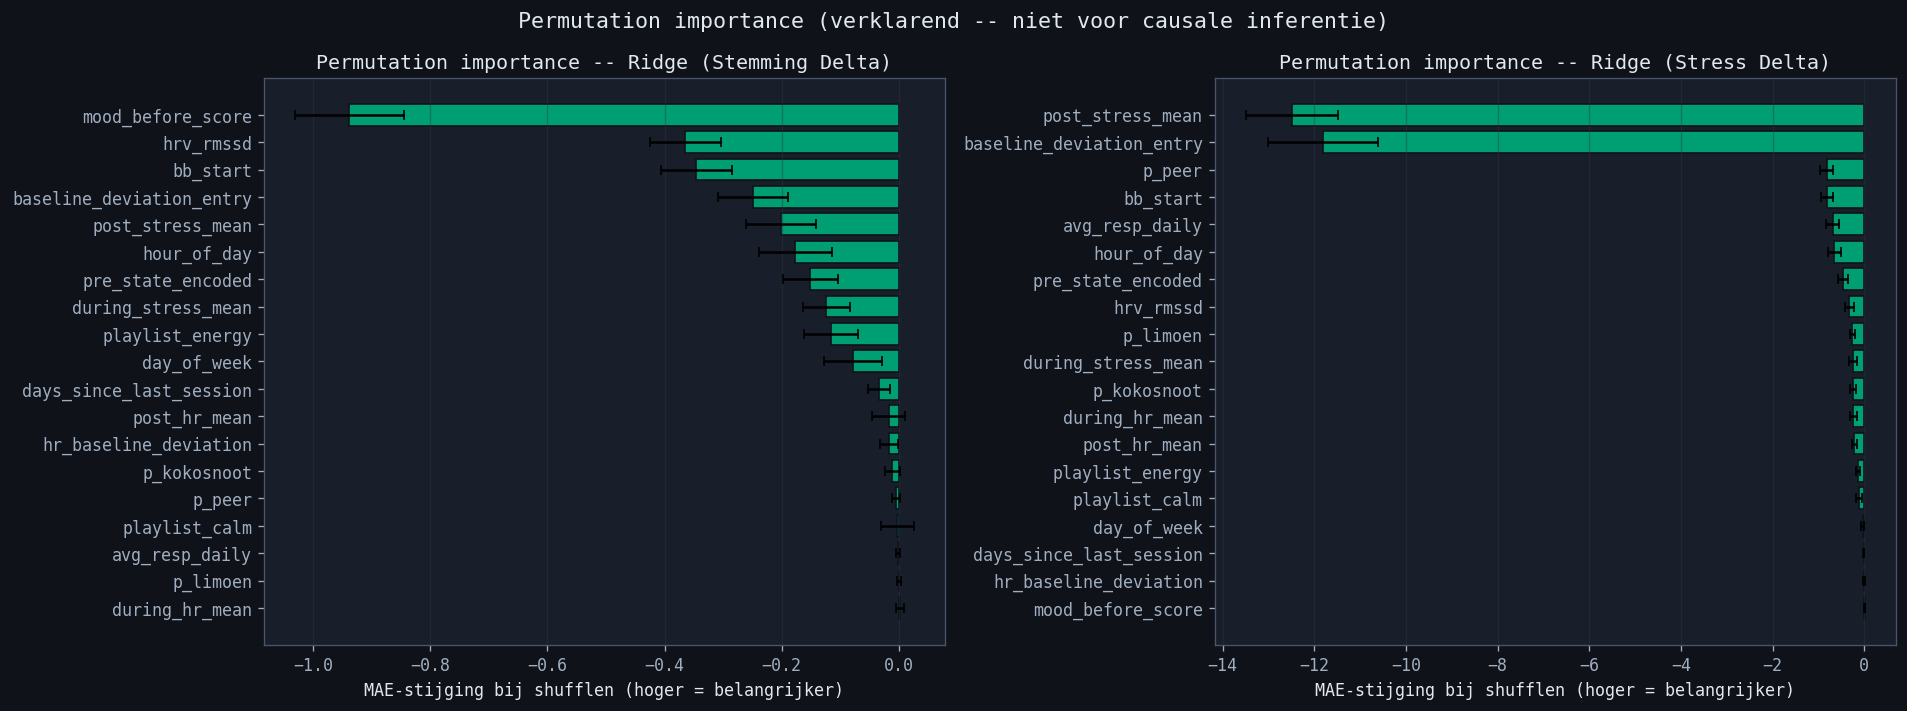

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (target, label) in zip(axes, TARGET_COLS.items()):
    if target not in all_fitted:
        continue
    comparison = all_comparisons[target]
    non_dummy  = comparison[comparison["model"] != "DummyMean"]
    best_name  = non_dummy.loc[non_dummy["MAE"].idxmin(), "model"]

    pipe   = all_fitted[target][best_name]
    X      = all_X[target]
    y      = all_y[target]

    result = permutation_importance(
        pipe, X, y, n_repeats=30, random_state=42,
        scoring="neg_mean_absolute_error",
    )
    perm_df = pd.DataFrame({
        "feature": list(X.columns),
        "mean":    result.importances_mean,
        "std":     result.importances_std,
    }).sort_values("mean", ascending=True)

    ax.barh(perm_df["feature"], -perm_df["mean"],
            xerr=perm_df["std"], color=OKABE_ITO[2],
            edgecolor="#0f1218", capsize=3)
    ax.set_xlabel("MAE-stijging bij shufflen (hoger = belangrijker)")
    ax.set_title(f"Permutation importance -- {best_name} ({label})", fontsize=12)
    ax.grid(True, axis="x")

fig.suptitle("Permutation importance (verklarend -- niet voor causale inferentie)", fontsize=13)
fig.tight_layout()
plt.show()

### 4c. SHAP -- gecombineerd

SHAP (SHapley Additive exPlanations) berekent per sessie de bijdrage van elke feature
aan de voorspelling, t.o.v. de gemiddelde voorspelling.

Het beeswarm-plot toont de verdeling van SHAP-waarden over alle sessies.
Kleur: rood = hoge feature-waarde, blauw = lage waarde.
Positieve SHAP = de feature draagt bij aan een hogere voorspelling.


SHAP -- Stemming Delta (Ridge, N=82)
Betrouwbaarheid: GRENSGEBIED -- voorzichtig interpreteren


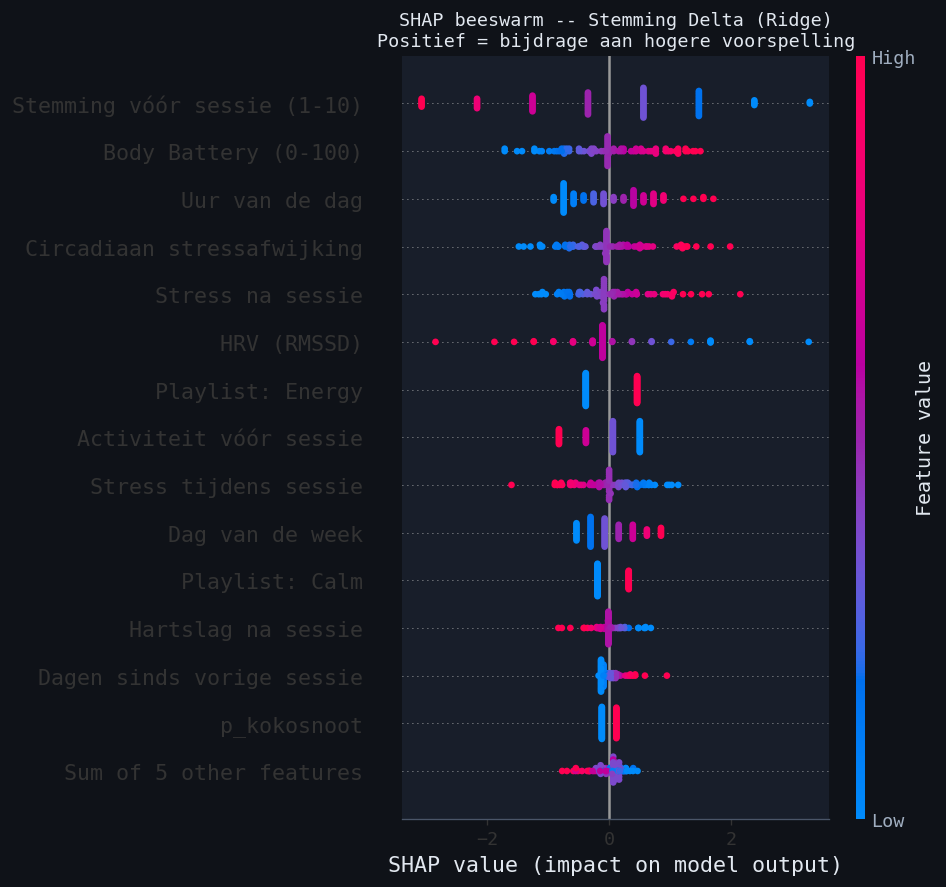


SHAP -- Stress Delta (Ridge, N=64)
Betrouwbaarheid: GRENSGEBIED -- voorzichtig interpreteren


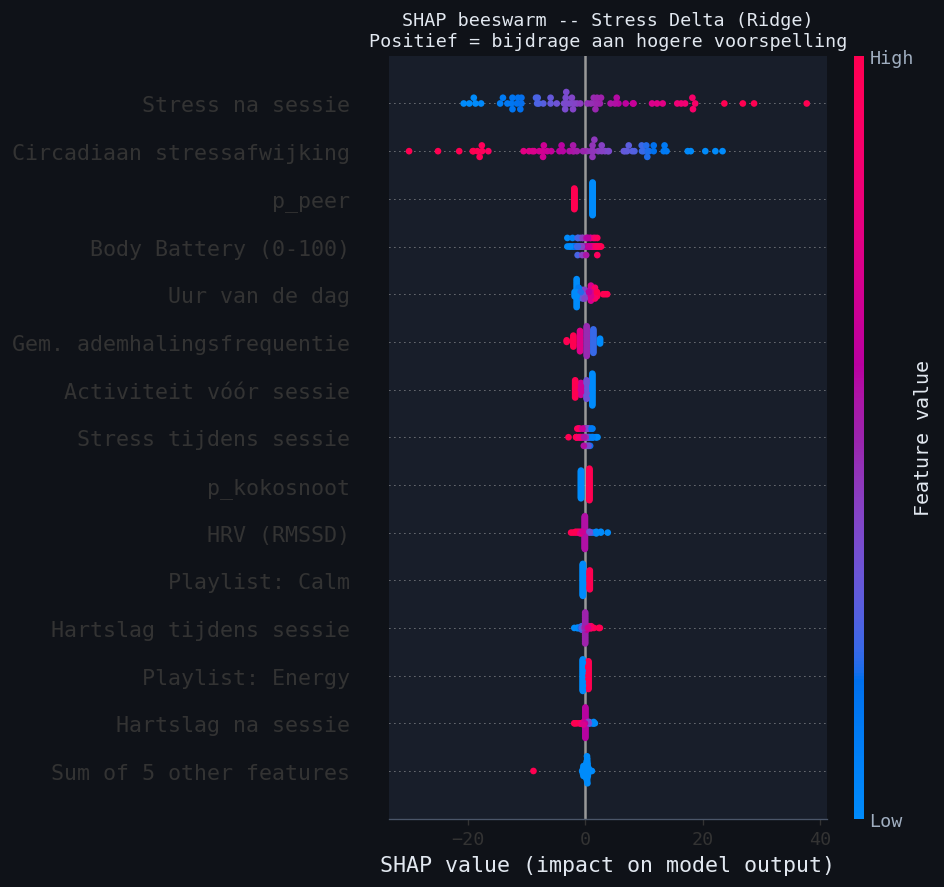

In [18]:
FEATURE_DISPLAY_NAMES = {
    "baseline_deviation_entry":   "Circadiaan stressafwijking",
    "hr_baseline_deviation":      "Circadiaan HR-afwijking",
    "hour_of_day":                "Uur van de dag",
    "day_of_week":                "Dag van de week",
    "playlist_calm":              "Playlist: Calm",
    "playlist_energy":            "Playlist: Energy",
    "mood_before_score":          "Stemming vóór sessie (1-10)",
    "bb_start":                   "Body Battery (0-100)",
    "days_since_last_session":    "Dagen sinds vorige sessie",
    "during_stress_mean":         "Stress tijdens sessie",
    "post_stress_mean":           "Stress na sessie",
    "during_hr_mean":             "Hartslag tijdens sessie",
    "post_hr_mean":               "Hartslag na sessie",
    "pre_state_encoded":          "Activiteit vóór sessie",
    "hrv_rmssd":                  "HRV (RMSSD)",
    "avg_resp_daily":             "Gem. ademhalingsfrequentie",
}

for target, label in TARGET_COLS.items():
    if target not in all_fitted:
        continue
    comparison = all_comparisons[target]
    non_dummy  = comparison[comparison["model"] != "DummyMean"]
    best_name  = non_dummy.loc[non_dummy["MAE"].idxmin(), "model"]

    pipe    = all_fitted[target][best_name]
    X       = all_X[target]
    imputer = pipe.named_steps["imputer"]

    X_imp = imputer.transform(X)
    kept  = [c for c, k in zip(X.columns, ~np.isnan(imputer.statistics_)) if k]
    X_imp = pd.DataFrame(X_imp, columns=kept)

    # Hernoem naar leesbare namen voor SHAP-weergave
    X_imp_display = X_imp.rename(columns=lambda c: FEATURE_DISPLAY_NAMES.get(c, c))

    model     = pipe.named_steps["model"]
    explainer = shap.Explainer(model, X_imp_display)
    shap_vals = explainer(X_imp_display)

    print(f"\nSHAP -- {label} ({best_name}, N={len(X)})")
    n_label = 'LAAG -- richtingwijzer' if len(X) < 40 else 'GRENSGEBIED -- voorzichtig interpreteren'
    print(f"Betrouwbaarheid: {n_label}")

    fig_sv, ax_sv = plt.subplots(figsize=(10, 6))
    plt.sca(ax_sv)
    shap.plots.beeswarm(shap_vals, show=False, max_display=15)
    ax_sv.set_title(f"SHAP beeswarm -- {label} ({best_name})\n"
                    f"Positief = bijdrage aan hogere voorspelling", fontsize=11)
    fig_sv.tight_layout()
    plt.show()

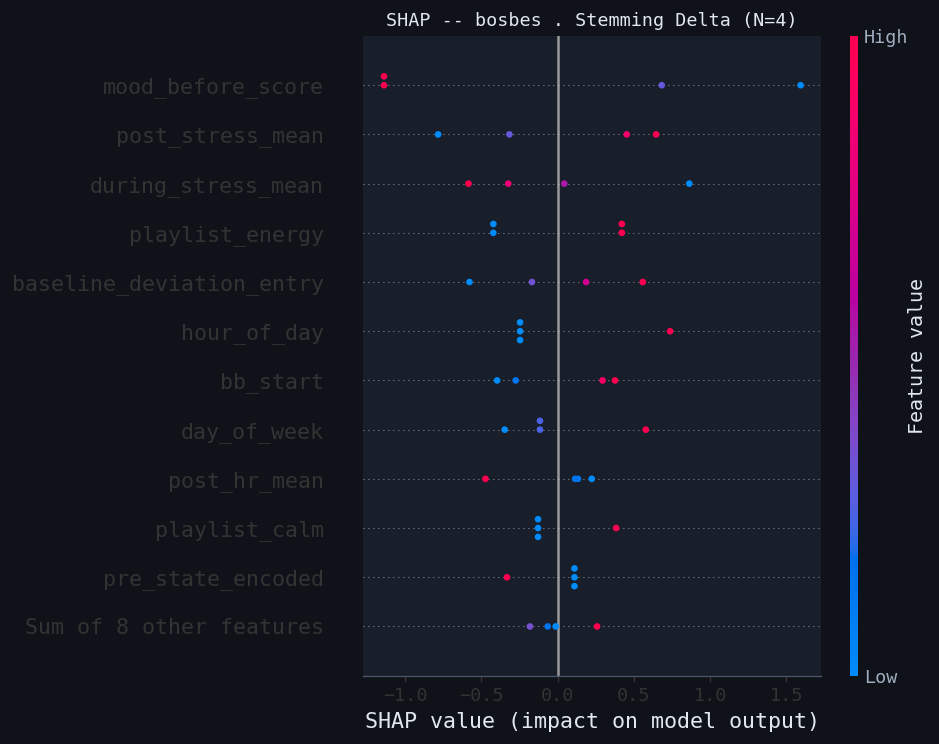

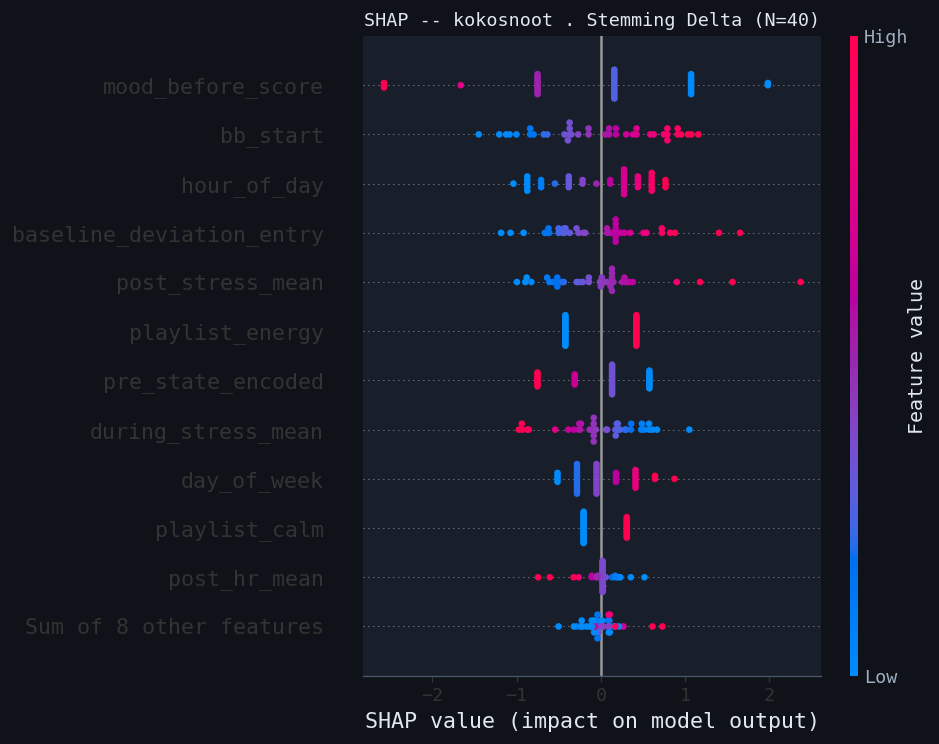

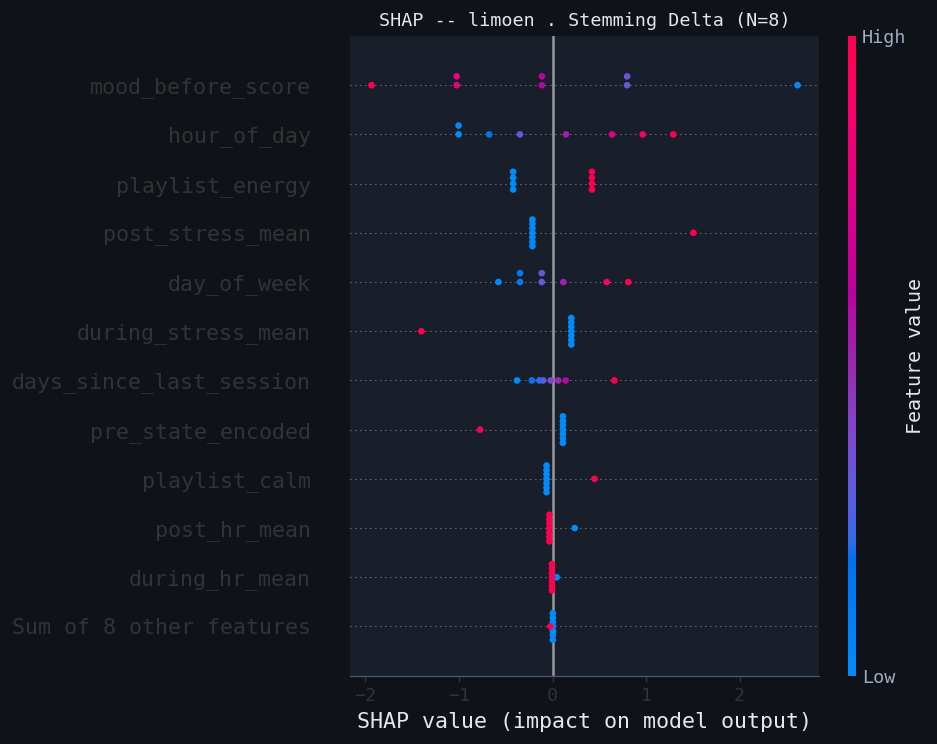

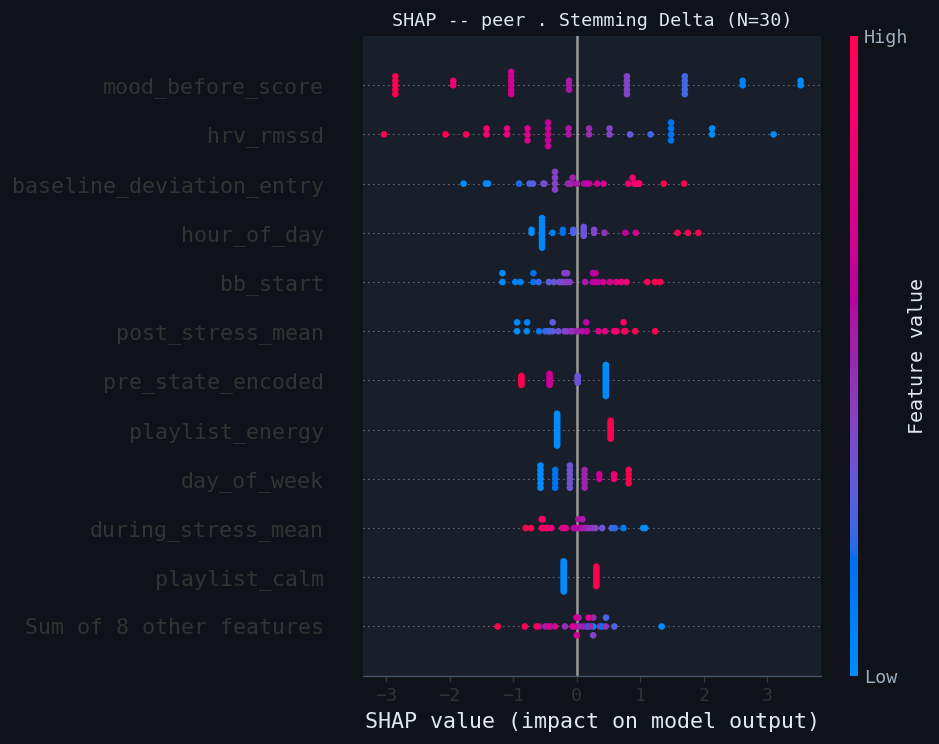

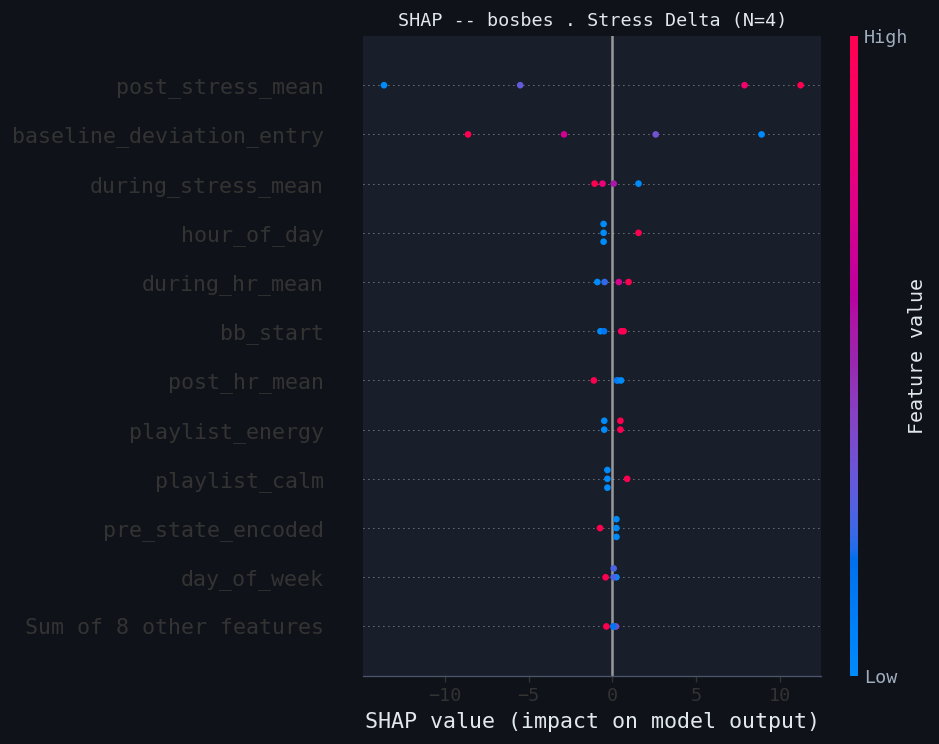

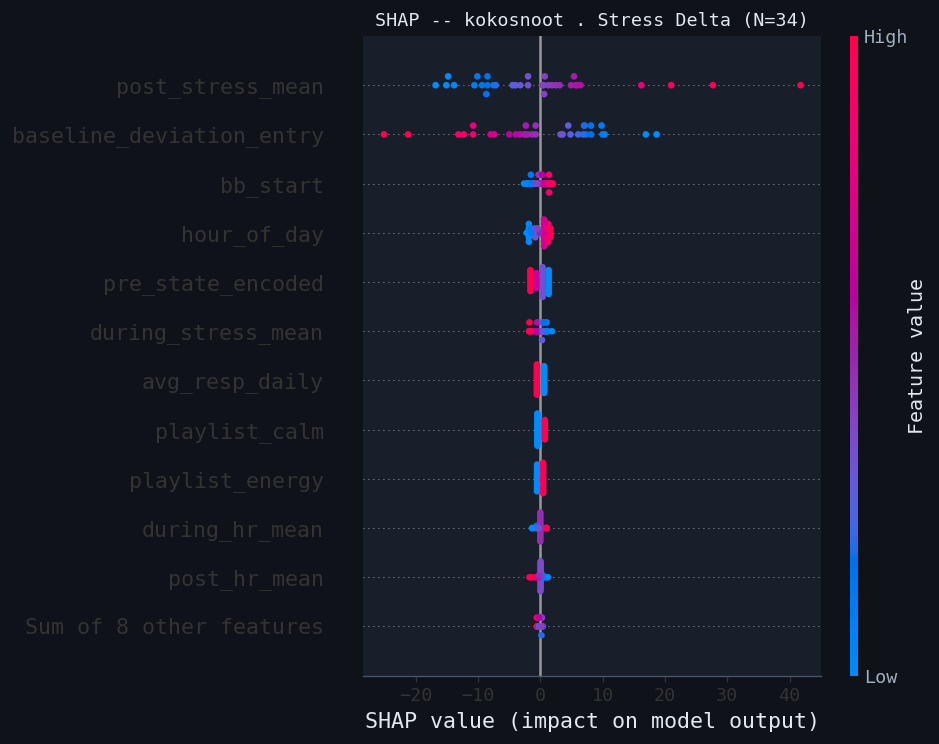

  limoen: te weinig sessies voor SHAP (1, minimum 3)


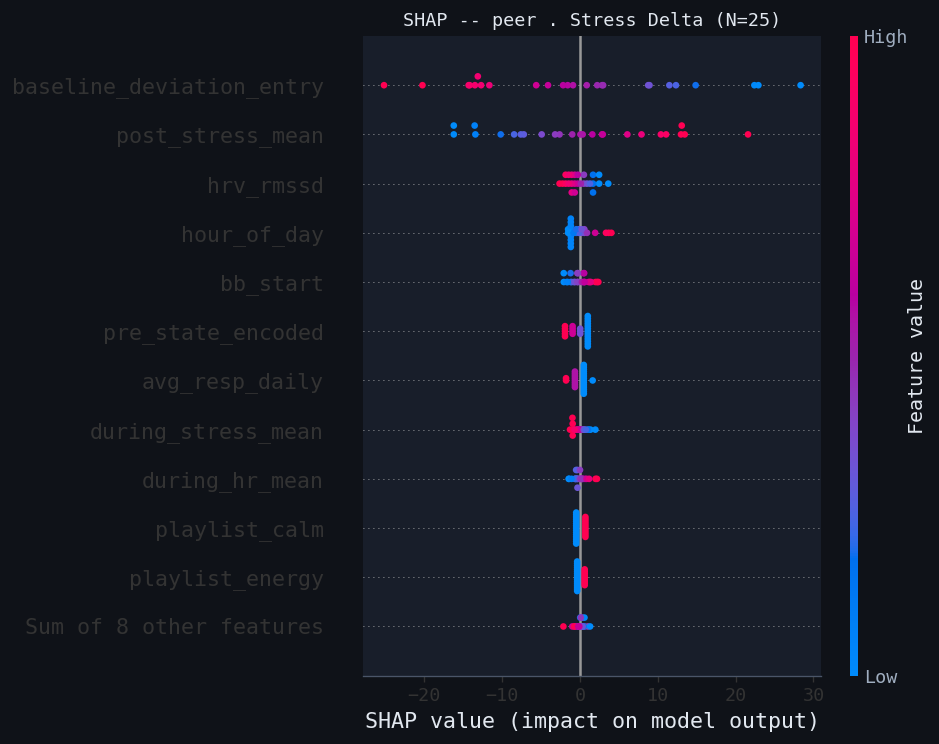

In [19]:
# SHAP per deelnemer (minimaal 3 sessies vereist)
for target, label in TARGET_COLS.items():
    if target not in all_fitted:
        continue
    comparison = all_comparisons[target]
    non_dummy  = comparison[comparison["model"] != "DummyMean"]
    best_name  = non_dummy.loc[non_dummy["MAE"].idxmin(), "model"]

    X      = all_X[target]
    y      = all_y[target]
    groups = all_groups[target]
    pipe   = all_fitted[target][best_name]

    for p in participants:
        mask = groups == p
        if mask.sum() < 3:
            print(f"  {p}: te weinig sessies voor SHAP ({mask.sum()}, minimum 3)")
            continue

        X_p      = X[mask]
        imputer  = pipe.named_steps["imputer"]
        X_imp    = imputer.transform(X_p)
        kept     = [c for c, k in zip(X_p.columns, ~np.isnan(imputer.statistics_)) if k]
        X_imp    = pd.DataFrame(X_imp, columns=kept)

        model     = pipe.named_steps["model"]
        explainer = shap.Explainer(model, X_imp)
        shap_vals = explainer(X_imp)

        fig_p, ax_p = plt.subplots(figsize=(9, 5))
        plt.sca(ax_p)
        shap.plots.beeswarm(shap_vals, show=False, max_display=12)
        ax_p.set_title(f"SHAP -- {p} . {label} (N={mask.sum()})", fontsize=11)
        fig_p.tight_layout()
        plt.show()

## 5. Stress delta -- verdeling

`stress_delta` = post_stress - pre_stress. Een **negatieve** waarde betekent
dat stress daalde tijdens de sessie (gewenst resultaat).

Limoen heeft slechts 1 geldige sessie voor dit target en wordt niet getoond.
Stress delta generaliseert beter dan mood delta: Ridge behaalt LOO-R2=0.87 vs 0.32.
Dit suggereert dat fysiologische stress systematischer reageert op de playlist context
dan zelfgerapporteerde stemming.

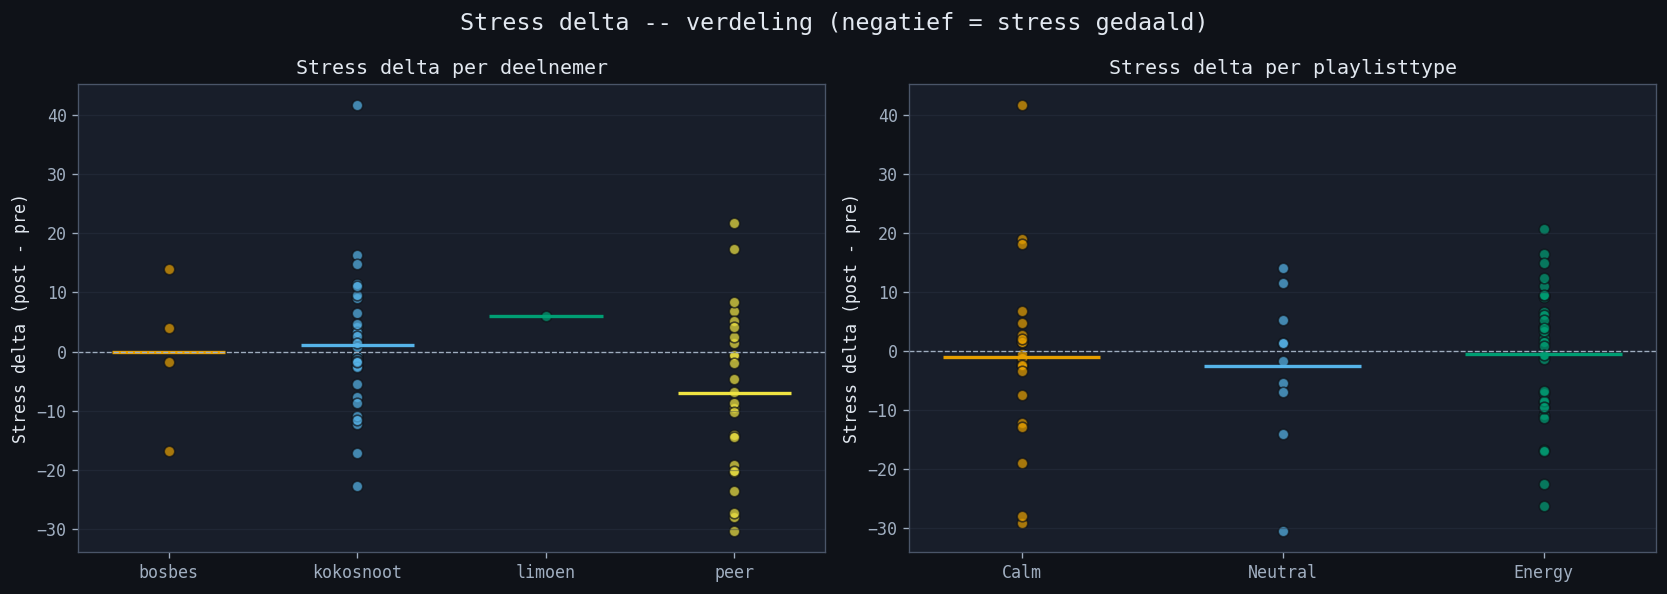

In [20]:
if "stress_delta" in all_y:
    y_sd      = all_y["stress_delta"]
    groups_sd = all_groups["stress_delta"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    for i, p in enumerate(groups_sd.unique()):
        vals = y_sd[groups_sd == p]
        ax.scatter([p] * len(vals), vals,
                   color=OKABE_ITO[i % len(OKABE_ITO)], alpha=0.7, s=40, edgecolors="#0f1218")
        ax.hlines(vals.mean(), i - 0.3, i + 0.3,
                  colors=OKABE_ITO[i % len(OKABE_ITO)], linewidth=2)
    ax.axhline(0, color="#a0aec0", linewidth=0.8, linestyle="--")
    ax.set_title("Stress delta per deelnemer", fontsize=12)
    ax.set_ylabel("Stress delta (post - pre)")
    ax.grid(True, axis="y")

    ax = axes[1]
    fm_sd = fm[fm["stress_delta"].notna()].copy() if "stress_delta" in fm.columns else fm.copy()
    if "playlist_type" not in fm_sd.columns:
        fm_sd["playlist_type"] = fm_sd.apply(playlist_label, axis=1)
    for i, ptype in enumerate(["Calm", "Neutral", "Energy"]):
        vals = fm_sd.loc[fm_sd["playlist_type"] == ptype, "stress_delta"]
        if vals.empty:
            continue
        ax.scatter([ptype] * len(vals), vals,
                   color=OKABE_ITO[i % len(OKABE_ITO)], alpha=0.7, s=40, edgecolors="#0f1218")
        ax.hlines(vals.mean(), i - 0.3, i + 0.3,
                  colors=OKABE_ITO[i % len(OKABE_ITO)], linewidth=2)
    ax.axhline(0, color="#a0aec0", linewidth=0.8, linestyle="--")
    ax.set_title("Stress delta per playlisttype", fontsize=12)
    ax.set_ylabel("Stress delta (post - pre)")
    ax.grid(True, axis="y")

    fig.suptitle("Stress delta -- verdeling (negatief = stress gedaald)", fontsize=14)
    fig.tight_layout()
    plt.show()

## 6. Robuustheidschecks

### 6a. Leave-One-Participant-Out (LOPO)

LOPO test of de geleerde patronen generaliseren **over deelnemers**: train op 3 deelnemers,
test op de 4e. Met slechts 4 deelnemers is dit een harde test. Als LOPO MAE veel hoger
is dan LOO MAE, zijn de patronen deelnemersspecifiek: het model leert de persoon kennen,
niet het algemene verband.

In [21]:
MODELS_LOPO = {
    "Ridge":            Ridge(alpha=1.0),
    "RandomForest":     RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                                   learning_rate=0.1, random_state=42),
}

logo = LeaveOneGroupOut()

for target, label in TARGET_COLS.items():
    if target not in all_X:
        continue
    X      = all_X[target]
    y      = all_y[target]
    groups = all_groups[target]

    print(f"\n{'='*50}")
    print(f"  LOPO -- {label}  (N={len(y)})")
    print(f"{'='*50}")

    for name, model in MODELS_LOPO.items():
        preds = np.full(len(y), np.nan)
        for train_idx, test_idx in logo.split(X, y, groups):
            pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model",   clone(model)),
            ])
            pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
            preds[test_idx] = pipe.predict(X.iloc[test_idx])
        mae     = mean_absolute_error(y, preds)
        loo_mae = all_comparisons[target].loc[
            all_comparisons[target]["model"] == name, "MAE"
        ].values[0]
        delta = mae - loo_mae
        print(f"  {name:20s}: LOPO MAE={mae:.3f}  (LOO MAE={loo_mae:.3f}, delta=+{delta:.3f})")


  LOPO -- Stemming Delta  (N=82)
  Ridge               : LOPO MAE=2.104  (LOO MAE=1.578, delta=+0.526)


  RandomForest        : LOPO MAE=1.646  (LOO MAE=1.666, delta=+-0.020)
  GradientBoosting    : LOPO MAE=1.671  (LOO MAE=1.778, delta=+-0.107)

  LOPO -- Stress Delta  (N=64)
  Ridge               : LOPO MAE=5.868  (LOO MAE=2.866, delta=+3.002)


  RandomForest        : LOPO MAE=7.377  (LOO MAE=6.437, delta=+0.940)
  GradientBoosting    : LOPO MAE=7.093  (LOO MAE=6.230, delta=+0.863)


### Interpretatie LOPO-resultaten

| Target | LOO MAE | LOPO MAE | Delta | Conclusie |
|---|---|---|---|---|
| mood_delta (Ridge) | 1.578 | 2.104 | +0.526 | Matig deelnemersspecifiek |
| stress_delta (Ridge) | 2.866 | 5.868 | **+3.002** | Sterk deelnemersspecifiek |

**stress_delta generaliseert NIET over deelnemers.** De Ridge-LOPO-kloof van +3.002 betekent
dat het model de stresspatronen van een specifieke deelnemer heeft geleerd, niet een algemeen
verband. Train je op deelnemers A, B en C en test je op D, dan neemt de MAE meer dan verdubbeld.

**Implicatie voor RQ4:** Voor stress_delta kan geen cross-participante voorspelling worden
geclaimd. De LOO-score (R²=0.87) is hoog maar artificieel — hij reflecteert deelnemersspecifieke
patronen. Voor mood_delta is de kloof kleiner (+0.526), wat wijst op zwakke maar aanwezige
generaliseerbare signalen.

**Interessant:** RF en GB generaliseren beter dan Ridge voor mood_delta (LOPO MAE 1.646 en 1.671
vs Ridge 2.104). Dit suggereert dat de lineaire Ridge-aannames niet ideaal zijn voor
cross-deelnemer generalisatie, maar Ridge blijft het meest betrouwbaar op LOO-niveau.

### 6b. Ablatie -- zonder `mood_before_score`

`mood_before_score` is sterk gecorreleerd met `mood_after_score`, waardoor het model
deels regressie-naar-het-gemiddelde kan leren in plaats van de echte sessie-invloed.

De ablatie test of de circadiaan features (`baseline_deviation_entry`, `hr_baseline_deviation`)
nog steeds bijdragen als `mood_before_score` wordt weggelaten.

In [22]:
target = "mood_delta"
if target in all_X:
    X     = all_X[target]
    y     = all_y[target]
    model = GradientBoostingRegressor(n_estimators=50, max_depth=2, learning_rate=0.1, random_state=42)
    loo   = LeaveOneOut()

    print(f"Ablatie -- {TARGET_COLS[target]}\n")

    for include_mood in [True, False]:
        lbl   = "MET mood_before_score" if include_mood else "ZONDER mood_before_score"
        X_sub = X[[c for c in X.columns if include_mood or c != "mood_before_score"]]

        y_pred = np.full(len(y), np.nan)
        for train_idx, test_idx in loo.split(X_sub):
            pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model",   clone(model)),
            ])
            pipe.fit(X_sub.iloc[train_idx], y.iloc[train_idx])
            y_pred[test_idx] = pipe.predict(X_sub.iloc[test_idx])

        mae = mean_absolute_error(y, y_pred)
        r2  = r2_score(y, y_pred)
        print(f"  {lbl}: MAE={mae:.3f}, R2_LOO={r2:.3f}")

Ablatie -- Stemming Delta



  MET mood_before_score: MAE=1.769, R2_LOO=0.121


  ZONDER mood_before_score: MAE=2.126, R2_LOO=-0.306


### 6c. Regressie naar het gemiddelde -- scatter

`mood_before_score` is de sterkste predictor van `mood_delta`. Een deel van dit signaal
kan regressie-naar-het-gemiddelde zijn: wie hoog scoort vóór de sessie heeft minder ruimte
om te verbeteren (plafondeffect), en omgekeerd.

De scatter hieronder toont de relatie. Als er een duidelijke negatieve helling is
(hoge startscore → negatieve delta), is regressie-naar-het-gemiddelde een aannemelijke verklaring.

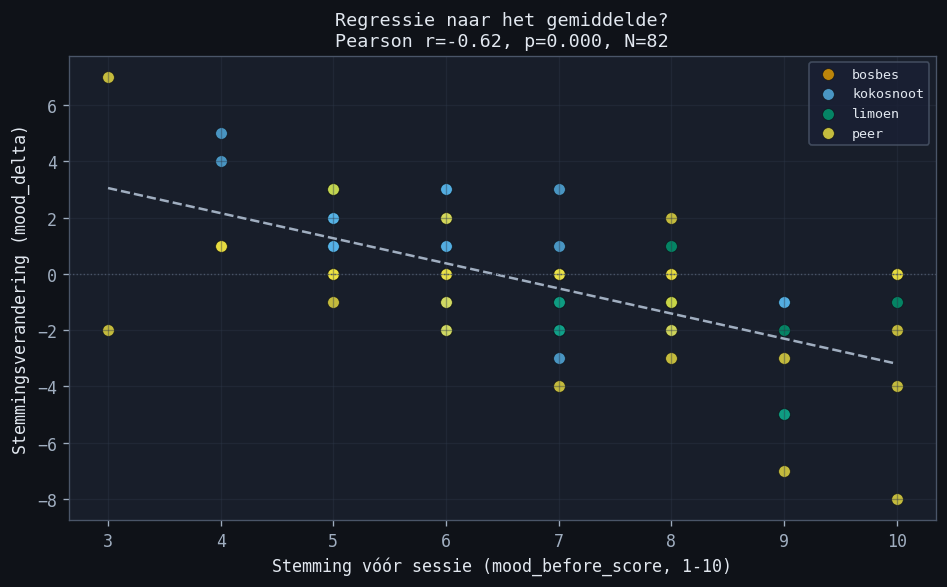

Negatief verband (r=-0.62): hogere startscore → kleinere stijging.
Regressie-naar-het-gemiddelde is een aannemelijke confound.


In [23]:
if "mood_delta" in all_X and "mood_before_score" in all_X["mood_delta"].columns:
    from scipy import stats as scipy_stats

    X_md   = all_X["mood_delta"]
    y_md   = all_y["mood_delta"]
    groups = all_groups["mood_delta"]

    mood_before = X_md["mood_before_score"].values
    mood_delta  = y_md.values
    valid_mask  = ~np.isnan(mood_before)

    r, p = scipy_stats.pearsonr(mood_before[valid_mask], mood_delta[valid_mask])

    fig, ax = plt.subplots(figsize=(8, 5))
    for i, part in enumerate(groups.unique()):
        mask = (groups == part).values & valid_mask
        ax.scatter(mood_before[mask], mood_delta[mask],
                   label=part, color=OKABE_ITO[i % len(OKABE_ITO)],
                   alpha=0.8, s=50, edgecolors="#0f1218", linewidths=0.5)

    # Regressielijn
    slope, intercept, *_ = scipy_stats.linregress(mood_before[valid_mask], mood_delta[valid_mask])
    x_line = np.array([mood_before[valid_mask].min(), mood_before[valid_mask].max()])
    ax.plot(x_line, slope * x_line + intercept, "--", color="#a0aec0", linewidth=1.5)

    ax.axhline(0, color="#4a5568", linewidth=0.8, linestyle=":")
    ax.set_xlabel("Stemming vóór sessie (mood_before_score, 1-10)")
    ax.set_ylabel("Stemmingsverandering (mood_delta)")
    ax.set_title(f"Regressie naar het gemiddelde?\n"
                 f"Pearson r={r:.2f}, p={p:.3f}, N={valid_mask.sum()}", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True)
    fig.tight_layout()
    plt.show()

    if r < -0.3:
        print(f"Negatief verband (r={r:.2f}): hogere startscore → kleinere stijging.")
        print("Regressie-naar-het-gemiddelde is een aannemelijke confound.")
    else:
        print(f"Zwak of geen negatief verband (r={r:.2f}): regressie-naar-het-gemiddelde is minder dominant.")

---

## 7. RQ3 -- Biometrische Classificatie van Playlisttype

**Onderzoeksvraag (RQ3):** *Kunnen we puur op basis van biometrische signalen achterhalen
welke playlist er is gebruikt?*

Dit is het **inverse probleem**: in plaats van mood te voorspellen gegeven het playlisttype,
proberen we het playlisttype te classificeren gegeven de biometrische respons.

Als dit mogelijk is, is het biometrische signaal voldoende onderscheidend tussen Calm,
Neutral en Energy — een sterke validatie van de ISO-aanpak.

**Features:** uitsluitend sessie-biometrie (geen pre-sessie mood, geen circadiaan afwijking).
**Modellen:** Logistic Regression (lineaire baseline) + Random Forest.
**CV:** StratifiedKFold (5 folds) om klassenbalans te bewaren per fold.

> **Verwachting:** Bij N≈82 en klassenonevenwicht (Calm≈34%, Neutral≈23%, Energy≈48%)
> zullen resultaten waarschijnlijk dicht bij kans liggen (~33% per klasse bij gelijkmatige
> verdeling). Dit is zelf een valide bevinding: biometrie alleen volstaat niet voor classificatie
> bij deze steekproefomvang.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Features: uitsluitend tijdens/na-sessie biometrie
RQ3_FEATURES = [
    "during_stress_mean",
    "post_stress_mean",
    "during_hr_mean",
    "post_hr_mean",
    "stress_delta",
]

# Target: playlisttype
if "playlist_type" not in fm.columns:
    fm["playlist_type"] = fm.apply(playlist_label, axis=1)

fm_rq3 = fm[RQ3_FEATURES + ["playlist_type"]].dropna(subset=["playlist_type"])
fm_rq3 = fm_rq3.dropna(thresh=len(RQ3_FEATURES) - 2)  # max 2 NaN per rij

X_rq3 = fm_rq3[RQ3_FEATURES]
y_rq3 = fm_rq3["playlist_type"]

print(f"RQ3 dataset: N={len(y_rq3)} sessies")
print("Klassenverdeling:")
print(y_rq3.value_counts().to_string())
print()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf",     LogisticRegression(C=1, max_iter=1000, random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf",     RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)),
    ]),
}

rq3_results = {}
for name, pipe in clf_models.items():
    y_pred_cv = cross_val_predict(pipe, X_rq3, y_rq3, cv=skf)
    rq3_results[name] = y_pred_cv
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_rq3, y_pred_cv, zero_division=0))

RQ3 dataset: N=72 sessies
Klassenverdeling:
playlist_type
Energy     34
Calm       27
Neutral    11

  Logistic Regression
              precision    recall  f1-score   support

        Calm       0.34      0.41      0.37        27
      Energy       0.49      0.56      0.52        34
     Neutral       0.00      0.00      0.00        11

    accuracy                           0.42        72
   macro avg       0.28      0.32      0.30        72
weighted avg       0.36      0.42      0.39        72



  Random Forest
              precision    recall  f1-score   support

        Calm       0.38      0.33      0.35        27
      Energy       0.49      0.68      0.57        34
     Neutral       0.00      0.00      0.00        11

    accuracy                           0.44        72
   macro avg       0.29      0.34      0.31        72
weighted avg       0.37      0.44      0.40        72



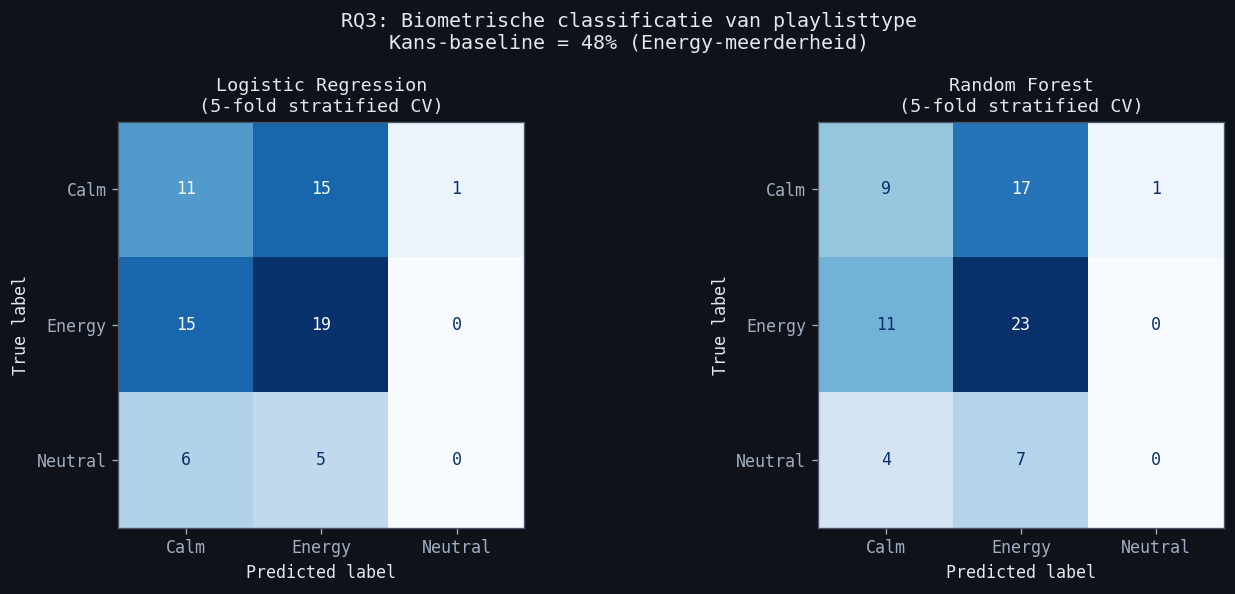


Conclusie RQ3:
Als accuracy ≈ 48% (=kans voor Energy-meerderheidsklasse), dan kan
biometrie alleen het playlisttype niet onderscheiden bij N≈82.
Dit is een valide bevinding: het biometrische signaal is niet scherp
genoeg voor automatische classificatie op deze steekproefomvang.


In [25]:
# Verwarringsmatrices
fig, axes = plt.subplots(1, len(rq3_results), figsize=(6 * len(rq3_results), 5))
if len(rq3_results) == 1:
    axes = [axes]

for ax, (name, y_pred_cv) in zip(axes, rq3_results.items()):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_rq3, y_pred_cv,
        display_labels=["Calm", "Energy", "Neutral"],
        colorbar=False,
        ax=ax,
        cmap="Blues",
    )
    ax.set_title(f"{name}\n(5-fold stratified CV)", fontsize=11)

fig.suptitle("RQ3: Biometrische classificatie van playlisttype\n"
             "Kans-baseline = 48% (Energy-meerderheid)", fontsize=12)
fig.tight_layout()
plt.show()

print("\nConclusie RQ3:")
print("Als accuracy ≈ 48% (=kans voor Energy-meerderheidsklasse), dan kan")
print("biometrie alleen het playlisttype niet onderscheiden bij N≈82.")
print("Dit is een valide bevinding: het biometrische signaal is niet scherp")
print("genoeg voor automatische classificatie op deze steekproefomvang.")